# Appendix E: the same model, implemented locally

**Read this after `main.ipynb`, not instead of it.** Nothing here changes a prediction, a
fixed point, a learned parameter or a figure. Code Cell E3 checks that claim against the output
`main.ipynb` recorded, line by line, rather than asserting it.

**What is outstanding in `main.ipynb`.** Text cell 3 §7 writes the plasticity rule for
$\theta_u$ as $\tau_\theta\dot\theta_u=\varphi_u\langle\varepsilon_S,b\rangle$, one presynaptic
activity times one pooled error signal, and Appendix B defends that as Hebbian. The implementation
runs at $m=2$, where the same rule reads $\sum_j\varphi_{u,j}\langle\varepsilon_S,b_j\rangle$: a sum
of products formed at $m$ synapses on $m$ **different** neurons. Appendix B says as much, that being
the structure the constraint of local plasticity forbids. So `main.ipynb` makes its locality claim at
$m=1$, where the claim is clean, and Appendix C then shows that $m=1$ is degenerate. The claim is
made where the model does not run.

**What this appendix does.** It inserts one node, and resolves the violation by relocating the sum
rather than by changing the arithmetic.

The $m$ columns of $B$ become the fixed terminal fields of the $m$ $\varphi_u$ axons on a descending
relay, so relay node $k$ receives $\sum_j B_{kj}\varphi_{u,j}$ as its own afferent sum. The quantity
Eq. (B4) had to gather from $m$ neurons is therefore already formed, as the relay's activity
$r=B\varphi_u$, before the learning rule is consulted. $\theta_u$ becomes the gain of the single
projection from the relay to $\varepsilon_S$, and its update is $\langle\varepsilon_S,r\rangle$, with
$r$ presynaptic and $\varepsilon_S$ postsynaptic on that one projection.

The sum over $j$ is not removed. It is moved out of the plasticity rule, where a synapse would have
had to read activity on other neurons, and into a dendrite, where summing one's own afferents is
what local computation permits. What is left in the rule is pooling across the $K$ terminals of one
projection, at any $m$, which is exactly the pooling Appendix B already commits to and defends.

**Why it is a separate appendix rather than a correction.** The relay buys locality and nothing
else. It is the harder object to hold in mind on a first pass, and every number it produces is a
number `main.ipynb` already produced, so nothing in the main line of argument depends on
reading it. `main.ipynb` stands as written.

## E.1 The equations

Four equations are added and three are replaced. Everything else in Text cell 3 stands verbatim.

### The relay

The relay is a population of $K$ nodes carrying no residual and no noise of its own. Each
$\varphi_{u,j}$ axon has fixed terminal field $b_j$ over it, so node $k$ receives
$\sum_j B_{kj}\varphi_{u,j}$ in its own dendrite:

$$\tau_r\,\dot r=B\varphi_u-r,
\qquad
r^\ast=B\varphi_u=\sum_{j=1}^m \varphi_{u,j}\,b_j\;\in\mathbb R^K.
\tag{E1}$$

$B$ is arborization density, fixed, exactly as in Text cell 3 §8.4. Nothing about the relay is
plastic.

### The three replacements

**Eq. (E2) replaces Eq. (10)** (and its $m>1$ lift $g_S=\theta_u B\varphi_u$ in §8.4). The generative
map is unchanged as a function of $\varphi_u$; what changes is where the product is formed:

$$g_S(\varphi_u)=\theta_u\,r
\qquad\text{in place of}\qquad
g_S(\varphi_u)=\theta_u\varphi_u b .
\tag{E2}$$

**Eq. (E3) replaces the second half of Eq. (19).** The ascending path runs back through the same
projection, so $\varphi_u$ receives the error pooled through each $b_j$ in turn:

$$\tau_\varphi\dot\varphi_u=-\varepsilon_u+\theta_u B^{\mathsf T}W\varepsilon_S
=-\varepsilon_u+\theta_u\big(\langle b_1,\varepsilon_S\rangle,\dots,
\langle b_m,\varepsilon_S\rangle\big)^{\mathsf T},
\tag{E3}$$

with $B^{\mathsf T}W$ as defined in Eq. (3). At $m=1$ this is Eq. (19) unchanged. The gain
$\theta_u$ is the same scalar in Eqs. (E2) and (E3), tied across the two directions exactly as
Bogacz ties $\Theta$ to $\Theta^{\mathsf T}$ (his Eqs. 53, 56); see § E.2.

**Eq. (E4) replaces Eq. (20)**, and is the point of the appendix:

$$\tau_\theta\,\dot\theta_u=\langle\varepsilon_S,r\rangle=\sum_{k=1}^K w_k\,\varepsilon_{S,k}\,r_k .
\tag{E4}$$

$r$ is the presynaptic activity at the $\theta_u$ synapse and $\varepsilon_S$ the postsynaptic
error; the sum runs over the $K$ terminals of that one projection. This is a product of pre- and
post-synaptic activity, and $m$ does not appear in it.

The two forms are the same number, not an approximation of one another:

$$\langle\varepsilon_S,B\varphi_u\rangle
=\varepsilon_S^{\mathsf T}WB\varphi_u
=\sum_{j=1}^m\varphi_{u,j}\langle\varepsilon_S,b_j\rangle .
\tag{E4a}$$

Eq. (E4a) is why no prediction moves: the left side is what the network now computes and the right
side is what Eq. (20) computed. Code Cell E2 measures the gap at $1.90\times10^{-15}$. Only the
right side is nonlocal, so it is the architecture and not the arithmetic that had to change.

### The new constraint

The relay is a third lag inside the loop $\varphi_u\to r\to\varepsilon_S\to\varphi_u$, whose gain is
$\theta_u^2\lambda_{\max}(B^{\mathsf T}WB)$. Holding $\varphi_S$ fixed and expanding in an
eigenmode of $B^{\mathsf T}WB$ with eigenvalue $\gamma$ (the identity, hence $\gamma=1$, for the
orthonormal $B$ of Text cell 3 §1), the loop closes on four variables and the question is a
spectrum:

$$\frac{\mathrm d}{\mathrm dt}
\begin{bmatrix}\varphi_u\\\varepsilon_S\\\varepsilon_u\\r\end{bmatrix}
=\begin{bmatrix}
0 & \theta_u\gamma/\tau_\varphi & -1/\tau_\varphi & 0\\
0 & -1/\tau_\varepsilon & 0 & -\theta_u/(\sigma_S\tau_\varepsilon)\\
1/(\sigma_u\tau_\varepsilon) & 0 & -1/\tau_\varepsilon & 0\\
1/\tau_r & 0 & 0 & -1/\tau_r
\end{bmatrix}
\begin{bmatrix}\varphi_u\\\varepsilon_S\\\varepsilon_u\\r\end{bmatrix}.
\tag{E5}$$

Two lags are stable at any gain; three are not (Åström & Murray, 2008, ch. 9). Collapsing the fourth
variable onto the first, which is what $r=B\varphi_u$ holding identically amounts to, returns the
instantaneous relay; that three-variable system is stable at every $\theta_u$. Carrying $r$ as a
variable in its own right is what can go unstable, and the question is how fast the relay then has
to be.

**Under the timescale commitment, no faster than the error units.** Code Cell E2 sweeps $\tau_r$ at
$\theta_u=-20$, $\theta_u^\ast$, $-40$ and $-80$ and finds the loop stable for every $\tau_r$ it
tests, up to $10^4\tau_\varepsilon$; the largest stable $\tau_r$ at or below $\tau_\varepsilon$ is
$\tau_\varepsilon$ itself, a ratio of $1.0000$ at every one of those $\theta_u$. So the ordering of
Text cell 3 §7 gains a term at its fast end, but only a weak one:

$$\tau_r\le\tau_\varepsilon\le\frac{\tau_\varphi}{4\lambda_{\max}(H)}\ll\tau_\varphi\ll\tau_\theta .
\tag{E6}$$

The $\theta_u^{-2}$ scaling has not disappeared; it has moved. Text cell 3 commitment 7 already
holds $\tau_\varepsilon$ below $\tau_\varphi/(4\lambda_{\max}(H))$, and $\lambda_{\max}(H)$ grows
as $\theta_u^2$, so a relay no slower than the error units inherits that scaling without a separate
requirement of its own. At $\theta_u^\ast=-28.4375$ the bound is $\tau_r\le3.08\times10^{-4}$, and
under the other priors of Part D it is $7.06\times10^{-9}$ (flat), $1.18\times10^{-3}$
($\mathrm{Beta}(1,3)$), $8.26\times10^{-5}$ ($\mathrm{Beta}(3,1)$) and $1.26\times10^{-7}$ (delta-like),
as Code Cell E4 prints: severe, but severe for a reason the main model already
carries.

The earlier reading of this appendix, that stability alone forces
$\theta_u^2\,\tau_{\mathrm{crit}}\to1$, is reproduced exactly as a **control** at
$\tau_\varepsilon=0.1$, the value the commitment forbids: the sweep returns $1.0257$, $1.0125$,
$1.0063$ and $1.0016$ at the four $\theta_u$. That boundary belongs to the slow error units, not to
the relay. What a slow relay still costs under the commitment is monotonicity rather than
convergence. Under *some*, at $\tau_r=\tau_\varepsilon$ no step of $\mathcal F$ decreases, at
$2\tau_\varepsilon$ six do, and at $10\tau_\varepsilon$ fifty-eight do, the worst by $-8.35$. Under *no* and
*all*, three steps already decrease at $\tau_r=\tau_\varepsilon$, nine at $2\tau_\varepsilon$ and sixty-five at
$10\tau_\varepsilon$, the worst by $-8.43$ (Code Cell E4).

Eq. (E6) therefore holds with $\le$ for stability under every utterance, and for a monotone
$\mathcal F$ under *some* only: under *no* and *all*, a relay at $\tau_r=\tau_\varepsilon$ already
lets $\mathcal F$ decrease. Making the bound strict, $\tau_r<\tau_\varepsilon$, would take more than
excluding the equality, since the strict inequality still admits relays arbitrarily close to
$\tau_\varepsilon$. It would require the largest ratio $\tau_r/\tau_\varepsilon$ at which no step of
$\mathcal F$ decreases under any of the three utterances, measured at every $\theta_u$ and prior
the bound is claimed for, and a bound placed at or below that ratio. Under *no* and *all* that
ratio, if one exists, lies below $1$, and it has not been measured.

### What is unchanged

| | |
|---|---|
| Eqs. (1)–(9) | the state space, the quadrature (2), (3), the clamped $\varphi_L$, and $g_L$ |
| Eq. (11) | unchanged as written, $r_S=\varphi_S-g_S(\varphi_u)$; only the expansion of $g_S$ is Eq. (E2) rather than Eq. (10) |
| Eq. (12) | the read-out |
| Eq. (13) | $\mathcal F$. The relay carries no residual, so it contributes no term |
| Eqs. (14)–(17) | the targets and the equilibrium identities |
| Eq. (18) | the error units |
| Eq. (19), first half | $\tau_\varphi\dot\varphi_S=-\varepsilon_S-\varepsilon_L$ |
| Eqs. (B1)–(B3) | the reduced objective and the stationarity quadratic. $\theta_u^\ast=-28.4375$ stands |
| Eqs. (21), (22) | the Hessian is negative definite. See § E.3 |
| Appendices A, C, D | untouched, including Eqs. (4), (A3) and (C1)–(C3) |

In [1]:
# === Code Cell E1: ARCHITECTURE, with the relay explicit ===
#
# Code Cell 1 of main.ipynb, with three additions and nothing removed:
#
#   relay()             r = B phi_u, Eq. (E1). The m-fold sum, formed in one node.
#   predict_state()     g_S = theta_u * r, Eq. (E2), and an optional explicit relay.
#   theta_u_gradient()  <eps_S, r>, Eq. (E4), in place of the column form of Eq. (20);
#                       theta_u_gradient_columns() keeps the old form for comparison.
#   infer(tau_relay=)   the relay's own dynamics, Eq. (E1), off by default, with the
#                       spectral guard of Eq. (E5).
#
# tau_relay=None is bit-for-bit the computation main.ipynb performed.

# === Code Cell 1: three-level predictive-coding network over a continuous
#     world state. ARCHITECTURE ===
#
# Implements the specification in the preceding markdown cell. Equation numbers below
# refer to that cell throughout.
#
# SIGN CONVENTION: F is Bogacz's negative free energy and is MAXIMIZED; every state
# equation is gradient ASCENT (spec preamble item 4, Eq. 13).

import math
import torch

DTYPE = torch.float64

UTTERANCES = ["no", "some", "all"]


# 1. NUMERICAL SUBSTRATE (spec Sec. 1)

def build_grid(num_nodes=101, half_width=6.0, dtype=DTYPE, device=None):
    """Fixed quadrature grid over zeta, with trapezoidal weights (Eqs. 1-2).

    The grid discretizes the integral, not the state: `num_nodes` is an accuracy
    parameter, and no quantity in the model is defined in terms of a state indexed
    by a node.
    """
    if num_nodes < 3:
        raise ValueError("num_nodes must be at least 3")
    if half_width <= 0:
        raise ValueError("half_width must be positive")

    zeta = torch.linspace(-half_width, half_width, num_nodes, dtype=dtype, device=device)
    spacing = (zeta[1] - zeta[0]).item()

    weights = torch.full_like(zeta, spacing)
    weights[0] *= 0.5
    weights[-1] *= 0.5
    return zeta, weights


def logistic(x):
    """s = sigma(zeta), recovering the proportion from its logit (Eq. 1)."""
    return torch.sigmoid(x)


# 2. LEXICON (spec Sec. 3, Eqs. 5-6)

def exclusion_indicator(utterance, zeta, theta_L, sharpness=None):
    """chi_y on the grid: 1 where the entry for `utterance` excludes the state (Eq. A1).

        E_no    ->  excluded where zeta >  -theta_L   (outside the cell of s=0)
        E_some  ->  excluded where zeta <= -theta_L   (inside  the cell of s=0)
        E_all   ->  excluded where zeta <   theta_L   (outside the cell of s=1)

    `theta_L` is semantic, not a parameter of the discretization: Appendix A gives its
    denotation (Eqs. A5-A6), the Voronoi reading of Eq. (A1), and the grid cap. The
    step is also the demanding case of Sec. 9.2 caveat 1.

    `sharpness=None` gives the step of the current phase (chi in {0, 1}); a positive
    float gives a logistic profile (chi in [0, 1]) for dense-scale predicates. Spec
    Sec. 8.1(iii) guarantees every convergence result is independent of this choice.
    """
    if utterance not in UTTERANCES:
        raise ValueError(f"utterance must be one of {UTTERANCES}")
    if theta_L <= 0:
        raise ValueError("theta_L must be positive")
    if sharpness is not None and sharpness <= 0:
        raise ValueError("sharpness must be positive when given")

    # signed distance into the excluded region, positive where excluded
    if utterance == "no":
        margin = zeta + theta_L
    elif utterance == "some":
        margin = -(zeta + theta_L)
    else:  # "all"
        margin = theta_L - zeta

    if sharpness is None:
        return (margin > 0).to(zeta.dtype)
    return torch.sigmoid(margin / sharpness)


# 3. BASE WORLD PRIORS (spec Sec. 3, the fixed quantity ell_0)

# ell_0 is a log-density in zeta. Because the state is carried in logit coordinates,
# a prior specified over the proportion s must be PUSHED FORWARD through the change of
# variables, picking up the Jacobian ds/dzeta = s(1-s). The distinction is not cosmetic:
# a distribution that is flat in s is NOT flat in zeta.

def gaussian_world_prior(mean=0.0, precision=1.0):
    """Gaussian in zeta: the default base prior ell_0 of Sec. 3, used when no elicited
    distribution is supplied. Sec. 3 gives the reason for a Gaussian default."""
    if precision <= 0:
        raise ValueError("precision must be positive")

    def log_density(zeta):
        return (
            0.5 * math.log(precision / (2.0 * math.pi))
            - 0.5 * precision * (zeta - mean).square()
        )

    log_density.description = f"Gaussian in zeta (mean {mean}, precision {precision})"
    return log_density


def beta_world_prior(alpha, beta):
    """Beta(alpha, beta) in s, pushed forward to zeta.

    With s = sigma(zeta) and ds/dzeta = s(1 - s), the Jacobian absorbs one factor from
    each side of the Beta density and the log-density collapses to

        log p(zeta) = alpha * log s + beta * log (1 - s) - log B(alpha, beta),

    evaluated through softplus for numerical stability. Note the exponents are alpha
    and beta rather than the usual alpha - 1 and beta - 1: that shift IS the Jacobian.

    Beta(1, 1) is the uniform prior over the proportion; alpha != beta is skewed.
    """
    if alpha <= 0 or beta <= 0:
        raise ValueError("alpha and beta must be positive")

    log_normalizer = (
        math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)
    )

    def log_density(zeta):
        log_s = -torch.nn.functional.softplus(-zeta)          # log sigma(zeta)
        log_one_minus_s = -torch.nn.functional.softplus(zeta)  # log (1 - sigma(zeta))
        return alpha * log_s + beta * log_one_minus_s - log_normalizer

    log_density.description = f"Beta({alpha}, {beta}) in s"
    return log_density


def uniform_world_prior():
    """Literal Uniform(0, 1) over the proportion.

    Implemented as its own case, NOT as the low-precision limit of the Gaussian:
    sending precision -> 0 inflates the variance in
    zeta and the sigmoid squashes the result into bimodal prior mass at the endpoints, which
    is the opposite of uniform. Uniform in s is Beta(1, 1), whose push-forward to zeta
    is the logistic density, unimodal about zeta = 0 and not flat there.
    """
    density = beta_world_prior(1.0, 1.0)
    density.description = "Uniform(0, 1) in s"
    return density


BASE_WORLD_PRIORS = {
    "gaussian": gaussian_world_prior(0.0, 1.0),
    "flat": uniform_world_prior(),
    "skewed low": beta_world_prior(1.0, 3.0),
    "skewed high": beta_world_prior(3.0, 1.0),
}


# 4. THE NETWORK

class LexicalPredictiveCodingNetwork:
    """y <- phi_L <- phi_S <- phi_u <- 1, with explicit error units.

    Clamped:      y, phi_L                       (Eqs. 6, 8)
    Variational:  phi_S, phi_u, and the error units    (fast, Eqs. 18-19)
                  theta_u                              (slow, Eq. 20)
    Fixed:        every sigma, Lambda, b, ell_0, mu_u, and the grid (Sec. 3)

    theta_u is LEARNED by default: `theta_u="learned"` sets it to theta_u*, the
    maximizer of F~ (Appendix B, Eq. B2), which is specific to every input and
    hyperparameter the network is built with, so `respawn` re-learns it on every
    override. A number instead of "learned" holds theta_u fixed, which the evaluation
    uses only as an explicitly stated control. The flow of Eq. (20) itself starts at
    `theta_u_initial` = 0, where the network is the TEMPERED control (theta_u = 0 at
    the model's sigmas), not the literal listener, which also needs sigma_S -> infinity.
    """

    def __init__(
        self,
        *,
        num_nodes=101,
        grid_half_width=6.0,
        base_prior=None,
        prior_mean=0.0,
        prior_precision=1.0,
        theta_L=None,
        num_atoms=10,
        lexical_strength=8.0,
        mu_u=1.0,
        theta_u="learned",
        theta_u_initial=0.0,
        basis_degree=2,
        sigma_lexical=1.0,
        sigma_state=1.0,
        sigma_utility=1.0,
        exclusion_sharpness=None,
        device=None,
    ):
        if prior_precision <= 0:
            raise ValueError("prior_precision must be positive")
        if lexical_strength <= 0:
            raise ValueError("lexical_strength (Lambda) must be positive")
        if theta_L is None and (int(num_atoms) != num_atoms or num_atoms < 2):
            raise ValueError(
                "num_atoms (n) must be an integer >= 2; below 2 the entries for "
                "\"some\" and \"all\" coincide"
            )
        if min(sigma_lexical, sigma_state, sigma_utility) <= 0:
            raise ValueError("variances must be positive")
        if min(sigma_lexical, sigma_state, sigma_utility) < 1.0:
            raise ValueError(
                "variances below 1 are outside the floor adopted in Sec. 3 "
                "(Friston 2005; Bogacz footnote 3)"
            )

        self.dtype = DTYPE
        self.device = device

        self.zeta, self.weights = build_grid(
            num_nodes=num_nodes,
            half_width=grid_half_width,
            dtype=self.dtype,
            device=device,
        )
        self.num_nodes = num_nodes

        # Fixed quantities (Sec. 3). Every sigma is carried symbolically although the
        # present phase fixes all three at 1, so that a later phase can unfix them
        # without the equations below changing shape.
        self.sigma_lexical = float(sigma_lexical)
        self.sigma_state = float(sigma_state)
        self.sigma_utility = float(sigma_utility)

        self.lexical_strength = float(lexical_strength)

        # LEXICAL THRESHOLD theta_L.
        #
        # logit is asymptotic at s = 0 and s = 1, so it is a bijection only on the OPEN
        # interval and the endpoints where Eq. (5) anchors "no" and "all" have no zeta
        # coordinate. Realizing E_y on the grid therefore requires a threshold
        # theta_L > 0, with E_y mapping to {zeta > -theta_L}, {zeta <= -theta_L} and
        # {zeta < theta_L} for "no", "some" and "all".
        #
        # theta_L is a generative weight of g_y, the lexical-content-to-word-form map:
        # recovering y from phi_L requires the threshold that produced it. Its gradient
        # is dF/dtheta_L = eps_y * dg_y/dtheta_L, which vanishes identically while
        # eps_y == 0 (Eq. 8), so theta_L is fixed BECAUSE phi_L is clamped rather than
        # by stipulation; unclamping phi_L makes it learnable.
        #
        # n is theta_L's denotation: sigma(-theta_L) = 1/(2n) (Eq. A5). A count where
        # the predicate has atoms, else 1/delta for a JND delta (Eq. A6, Appendix A).
        if theta_L is None:
            self.theta_L = math.log(2 * int(num_atoms) - 1)
        else:
            self.theta_L = float(theta_L)
        if self.theta_L <= 0:
            raise ValueError("theta_L must be positive")
        # derived from theta_L (Eq. A5), not an independent quantity
        self.num_atoms = (math.exp(self.theta_L) + 1.0) / 2.0
        if self.theta_L >= grid_half_width:
            raise ValueError(
                f"theta_L = {self.theta_L:.4f} exceeds the grid half-width "
                f"{grid_half_width}: E_no leaves no grid node unexcluded. Widen the "
                f"grid, or lower n (n = {self.num_atoms:.4g} requires half_width > "
                f"{self.theta_L:.4f})."
            )
        self.exclusion_sharpness = exclusion_sharpness
        # theta_u is resolved at the end of the constructor, once ell_0, B and mu_u exist:
        # "learned" needs all three (Eq. B2).
        if not (theta_u == "learned" or isinstance(theta_u, (int, float))):
            raise ValueError('theta_u must be "learned" or a number (a fixed control)')
        self.theta_u_initial = float(theta_u_initial)


        # UTILITY BASIS B (K x m). The default m = 2 takes zeta and zeta^2, orthonormalized under the
        # quadrature inner product against the constant function and each other. The
        # linear component separates "no" from {"some", "all"} and the quadratic
        # separates "some" from {"no", "all"}, so all three utterances receive
        # distinct projections.
        if basis_degree < 1:
            raise ValueError("basis_degree must be at least 1")
        self.basis_degree = int(basis_degree)

        raw = [torch.ones_like(self.zeta)] + [
            self.zeta ** d for d in range(1, self.basis_degree + 1)
        ]
        orthonormal = []
        for vector in raw:
            for previous in orthonormal:
                vector = vector - self.inner(vector, previous) * previous
            norm = torch.sqrt(self.inner(vector, vector))
            if float(norm) <= 1e-12:
                raise ValueError("basis degenerated during orthonormalization")
            orthonormal.append(vector / norm)
        # discard the constant, keep the m read-out-relevant directions
        self.basis = torch.stack(orthonormal[1:], dim=1)          # (K, m)
        self.num_basis = self.basis.shape[1]

        # mu_u: the weight on the terminating tonic node, one per basis direction.
        # Scalars broadcast.
        #
        # mu_u MUST BE NONZERO. The terminating contribution to g_S is theta_u * B * mu_u,
        # so at mu_u = 0 it is identically zero for every theta_u: the chain stops rather
        # than terminates, phi_u loses its anchor, and theta_u becomes unidentifiable --
        # it diverges by shifting magnitude out of the priced factor phi_u into the
        # unpriced theta_u along the exact degeneracy (theta_u, phi_u) -> (c theta_u,
        # phi_u / c), which leaves g_S invariant. This is not a departure from Bogacz:
        # his Eq. (25) model diverges identically at v_p = 0 (argmax theta = u / v_p).
        # v_p != 0 is an unstated premise of his construction, whose worked example
        # takes v_p = 3. The value 1.0 is a stipulation; a terminating prior is a fixed
        # boundary condition and has no target to be derived from.
        mu_u_tensor = torch.as_tensor(mu_u, dtype=self.dtype, device=device)
        if mu_u_tensor.ndim == 0:
            mu_u_tensor = mu_u_tensor.expand(self.num_basis).clone()
        if mu_u_tensor.shape != (self.num_basis,):
            raise ValueError(f"mu_u must be a scalar or have shape ({self.num_basis},)")
        self.mu_u = mu_u_tensor

        # Base world log-prior ell_0 (Sec. 3). `base_prior` is any callable
        # zeta -> log-density; when omitted, `gaussian_world_prior` at the given
        # mean and precision.
        #
        # The result is renormalized against the quadrature measure so that
        # sum_k w_k exp(ell_0) = 1 exactly on the truncated grid. An analytically
        # normalized density is not grid-normalized once the grid is cut off, and the
        # spec (Sec. 9.1) notes that phi_S is pinned in absolute terms, so the constant
        # is worth getting right even though it happens to be invisible here: B is
        # orthogonal to the constant function by construction, so <1, b_j> = 0 and an
        # additive shift in ell_0 reaches neither phi_u* (Eq. 16) nor the read-out.
        if base_prior is None:
            base_prior = gaussian_world_prior(prior_mean, prior_precision)
        if not callable(base_prior):
            raise TypeError("base_prior must be a callable zeta -> log-density")

        self.prior_mean = float(prior_mean)
        self.prior_precision = float(prior_precision)
        self.base_prior = base_prior
        self.base_prior_description = getattr(base_prior, "description", "custom")

        raw_log_prior = base_prior(self.zeta)
        if raw_log_prior.shape != self.zeta.shape:
            raise ValueError("base_prior must return one log-density per grid node")
        shift = raw_log_prior.max()
        prior_grid_mass = torch.sum(self.weights * torch.exp(raw_log_prior - shift))
        self.base_log_prior = raw_log_prior - shift - torch.log(prior_grid_mass)

        # retained so that probe networks can be respawned with the same configuration
        self._configuration = dict(
            num_nodes=num_nodes,
            grid_half_width=grid_half_width,
            base_prior=base_prior,
            prior_mean=prior_mean,
            prior_precision=prior_precision,
            theta_L=theta_L,
            num_atoms=num_atoms,
            lexical_strength=lexical_strength,
            mu_u=self.mu_u.clone(),
            theta_u=theta_u,
            theta_u_initial=theta_u_initial,
            basis_degree=basis_degree,
            sigma_lexical=sigma_lexical,
            sigma_state=sigma_state,
            sigma_utility=sigma_utility,
            exclusion_sharpness=exclusion_sharpness,
            device=device,
        )

        # theta_u: learned (theta_u*, Eq. B2) unless a fixed control value is given.
        # "learned" is what `_configuration` carries, so every respawn re-learns it for
        # its own inputs and hyperparameters (a variational theta_u is a commitment of
        # the model, not a setting carried over between configurations).
        self.theta_u_learned = theta_u == "learned"
        self.theta_u = (
            self.learned_theta_u() if self.theta_u_learned else float(theta_u)
        )

    def respawn(self, **overrides):
        """A new network with this one's configuration, plus any overrides.

        theta_u is re-learned for the new configuration unless the override, or the
        configuration being copied, fixes it to a number."""
        return LexicalPredictiveCodingNetwork(**{**self._configuration, **overrides})

    # === quadrature (Eq. 2) ===

    def inner(self, f, h):
        """<f, h> under the fixed quadrature measure (Eq. 2)."""
        return torch.sum(self.weights * f * h)

    def project(self, f):
        """B^T W f: contract a field onto the m basis directions (Eq. 3)."""
        return torch.mv(self.basis.T, self.weights * f)

    def squared_norm(self, f):
        return self.inner(f, f)

    @staticmethod
    def dot(a, b):
        """Ordinary inner product, for the utility vector (no quadrature measure)."""
        return torch.sum(a * b)

    # === clamped lexical field (Eqs. 5-6) ===

    def lexical_field(self, utterance):
        """phi_L = Lambda * chi_y, clamped by the observed utterance."""
        chi = exclusion_indicator(
            utterance,
            self.zeta,
            self.theta_L,
            sharpness=self.exclusion_sharpness,
        )
        return self.lexical_strength * chi

    # === generative pass (Sec. 4) ===

    def predict_lexical(self, phi_S):
        """g_L(phi_S) = ell_0 - phi_S (Eq. 9).

        The complement, transported to log-weights and reflected through the base world
        prior rather than through zero. Still an affine involution --
        g_L(g_L(x)) = x, so the structure of Eq. (9) is unchanged; ell_0 supplies the
        reference point the complement is taken about."""
        return self.base_log_prior - phi_S

    def relay(self, phi_u):
        """r = B phi_u: the activity of the descending relay between u and S.

        The m columns of B are the fixed terminal fields of the m phi_u axons, so
        relay node k forms the sum over j in its OWN dendrite. That is what makes
        Eq. (20) local at m > 1: theta_u is the gain of the single topographic
        projection r -> eps_S, so its Hebbian product pools across the K terminals of
        that one projection and never across the m columns, which is the sharing
        Bogacz's Sec. 5 rejects for Sigma.

        r is a deterministic linear image of phi_u carrying no error node and no
        noise of its own, so g_S is the same map it was and Secs. 8.1-8.4 are
        untouched. The prose in Sec. 7 and Appendix B is still written at m = 1 and
        has NOT yet been lifted to this reading; that edit is outstanding."""
        return torch.mv(self.basis, phi_u)

    def predict_state(self, phi_u, theta_u=None, relay=None):
        """g_S(phi_u) = theta_u * r, with r = B phi_u (Eq. 10, and M = B theta_u of
        Sec. 8.4).

        ell_0 has moved to g_L, so the utility level's prediction of the situation is
        now purely its own contribution, with no tonic offset. `theta_u=None` uses the
        network's own theta_u, which is theta_u* unless it was fixed as a control.

        Passing `relay` substitutes an explicitly integrated relay state for r (see
        infer's tau_relay). The relay's own fixed point is r = B phi_u, so this
        changes the transient and not the fixed point."""
        theta = self.theta_u if theta_u is None else float(theta_u)
        field = self.relay(phi_u) if relay is None else relay
        return theta * field

    def residuals(self, phi_S, phi_u, phi_L, theta_u=None, relay=None):
        """r_L, r_S, r_u of Eq. (11). r_y == 0 by Eq. (8) and is omitted; Appendix A
        gives its space (Eq. 4) and why omitting it is safe (Eq. A3)."""
        r_lexical = phi_L - self.predict_lexical(phi_S)
        r_state = phi_S - self.predict_state(phi_u, theta_u=theta_u, relay=relay)
        r_utility = phi_u - self.mu_u
        return r_lexical, r_state, r_utility

    def free_energy(self, phi_S, phi_u, phi_L, theta_u=None, relay=None):
        """Bogacz's F, to be MAXIMIZED (Eq. 13). The log-sigma terms vanish at
        sigma = 1 and are constant in every variational quantity; they are carried
        only to mark where a precision-bearing version would reintroduce them."""
        r_lexical, r_state, r_utility = self.residuals(
            phi_S, phi_u, phi_L, theta_u=theta_u, relay=relay
        )
        quadratic = (
            -0.5 * self.squared_norm(r_lexical) / self.sigma_lexical
            - 0.5 * self.squared_norm(r_state) / self.sigma_state
            - 0.5 * self.dot(r_utility, r_utility) / self.sigma_utility
        )
        normalizer = -0.5 * (
            self.num_nodes * math.log(self.sigma_lexical)
            + self.num_nodes * math.log(self.sigma_state)
            + self.num_basis * math.log(self.sigma_utility)
        )
        return quadratic + normalizer

    # === read-out (Eq. 12) ===

    def read_out(self, phi_S):
        """Normalized belief q(zeta_k), computed in log-space (Sec. 9.2 caveat 2)."""
        shifted = phi_S - phi_S.max()
        unnormalized = torch.exp(shifted)
        return unnormalized / torch.sum(self.weights * unnormalized)

    # === closed-form targets (Sec. 6) ===

    def closed_form_fixed_point(self, utterance, theta_u=None):
        """Eqs. (15)-(16), generalized to arbitrary fixed sigma and to B of Sec. 8.4.

        Writing S = sigma_L + sigma_S, G = B^T W B and c = B^T W (ell_0 - phi_L),

            (I + sigma_u theta^2 G / S) phi_u* = mu_u + sigma_u theta c / S
            phi_S* = [sigma_L theta B phi_u* + sigma_S (ell_0 - phi_L)] / S

        The signs follow ell_0 having moved into g_L (Eq. 9): the utility level couples
        to the NET ell_0 - phi_L where it coupled to the sum ell_0 + phi_L before.

        At sigma = 1 and m = 1 these reduce to Eqs. (15)-(16) as written. G = I for the
        orthonormal basis built above, but the m x m system is solved in general so the
        result stays correct if a later phase supplies a non-orthonormal B.

        Because the model is linear-Gaussian while phi_L is clamped (Sec. 8.6), these
        are exact, and they are the correctness test for `infer`.
        """
        theta = self.theta_u if theta_u is None else float(theta_u)
        phi_L = self.lexical_field(utterance)
        total_sigma = self.sigma_lexical + self.sigma_state

        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        # ell_0 now enters through g_L, so the utility level couples to the NET of prior
        # and lexicon, ell_0 - phi_L, where before it coupled to their sum.
        coupling = self.project(self.base_log_prior - phi_L)

        matrix = (
            torch.eye(self.num_basis, dtype=self.dtype, device=self.device)
            + self.sigma_utility * theta ** 2 * gram / total_sigma
        )
        rhs = self.mu_u + self.sigma_utility * theta * coupling / total_sigma
        phi_u_star = torch.linalg.solve(matrix, rhs)

        phi_S_star = (
            self.sigma_lexical * self.predict_state(phi_u_star, theta_u=theta)
            + self.sigma_state * (self.base_log_prior - phi_L)
        ) / total_sigma

        return phi_S_star, phi_u_star

    # === the literal listener (Part C, Part D) ===

    def literal_fixed_point(self, utterance):
        """phi_S of the LITERAL listener: the base world prior restricted by the entry.

        phi_S = ell_0 - phi_L, whose read-out is q_lit proportional to
        p_0 * exp(-Lambda chi_y): the prior times the soft semantic mask, and nothing
        else. This is the baseline the strengthening conditions of Text cell 4 Part C
        are measured against.

        It is a fixed point of THIS network, not an external construction. Eq. (15)
        reads phi_S* = [sigma_L theta_u B phi_u + sigma_S (ell_0 - phi_L)] / S with
        S = sigma_L + sigma_S, so sigma_S -> infinity sends it to ell_0 - phi_L: the
        situation level keeps no prior of its own and the lexical channel alone fixes
        the belief. That limit is what "literal" means here.

        NOT the same as theta_u = 0. At theta_u = 0 the r_S term still penalizes phi_S
        against a prediction of zero, which leaves phi_S* = (ell_0 - phi_L)/2 -- the
        literal posterior TEMPERED by one half, since the read-out (Eq. 12) is
        exponential. The half is a genuine temperature, so the theta_u = 0 belief is
        flatter than the literal one and holds systematically more mass at the ends of
        the scale. Both are reported below: this is the baseline, and theta_u = 0 is
        kept beside it as the temperature-matched control. The tempered control is
        also where the flow of Eq. (20) starts (`theta_u_initial`); the literal
        listener is not.
        """
        return self.base_log_prior - self.lexical_field(utterance)

    # === the learned theta_u (Sec. 8.5, Appendix B) ===

    def theta_u_stationary_points(self, utterances=None):
        """Both roots of Eq. (B2): (theta_u*, theta_min), the maximizer and the minimum.

        Eliminating phi_S and phi_u (exact by Sec. 8.6) reduces F, averaged over the
        exposure ensemble `utterances` (default: the three utterances at uniform
        p(y), Appendix B), to

            F~(theta) = const - sum_y ||theta mu_u - c_y||^2 / (2 (sigma_u theta^2 + S)),
                S = sigma_L + sigma_S,        c_y = B^T W (ell_0 - phi_L,y),

        whose stationarity condition is the quadratic

            sigma_u <mu_u, sum c> theta^2 + (n S ||mu_u||^2 - sigma_u sum ||c_y||^2) theta
                                                          - S <mu_u, sum c> = 0,

        n the number of utterances. The roots have product -S / sigma_u < 0: exactly one
        of each sign, the maximizer being the one with sign <mu_u, sum c>. The reduction
        uses G = B^T W B = I, which the basis built above satisfies.
        """
        utterances = UTTERANCES if utterances is None else list(utterances)
        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        identity = torch.eye(self.num_basis, dtype=self.dtype, device=self.device)
        if float((gram - identity).abs().max()) > 1e-10:
            raise NotImplementedError(
                "the closed form of Eq. (B2) assumes B^T W B = I (the basis built here)"
            )
        couplings = [self.project(self.base_log_prior - self.lexical_field(y))
                     for y in utterances]
        total = torch.stack(couplings).sum(dim=0)
        S = self.sigma_lexical + self.sigma_state
        a = self.sigma_utility * float(self.dot(self.mu_u, total))
        if a == 0.0:
            raise ValueError(
                "<mu_u, sum_y c_y> = 0: F~ has no interior maximizer and theta_u "
                "diverges (Appendix B's degenerate ray)"
            )
        b = (len(utterances) * S * float(self.dot(self.mu_u, self.mu_u))
             - self.sigma_utility * sum(float(self.dot(c, c)) for c in couplings))
        c0 = -S * a / self.sigma_utility
        root = math.sqrt(b * b - 4.0 * a * c0)       # discriminant > 0: a * c0 < 0
        # numerically stable pair: q = -(b + sign(b) root) / 2
        q = -0.5 * (b + math.copysign(root, b))
        roots = (q / a, c0 / q)
        maximizer = roots[0] if (roots[0] > 0) == (a > 0) else roots[1]
        minimum = roots[1] if maximizer == roots[0] else roots[0]
        return maximizer, minimum

    def learned_theta_u(self, utterances=None):
        """theta_u*, the maximizer of F~ (Eq. B2): the value Eq. (20) ascends to."""
        return self.theta_u_stationary_points(utterances)[0]

    # === Hessian check (Eq. 21) ===

    def hessian_quadratic_form(self, v, t, theta_u=None):
        """(v, t)^T grad^2 F (v, t) of Eq. (21), in the sigma-weighted form

            -||v||^2/sigma_L - ||v - theta_u B t||^2/sigma_S - ||t||^2/sigma_u,

        obtained by reading off the directional derivative of each residual. Strictly
        negative for (v, t) != 0, for every theta_u and every Lambda (Sec. 8.1), and
        for arbitrary B and m (Sec. 8.4).
        """
        theta = self.theta_u if theta_u is None else float(theta_u)
        return (
            -self.squared_norm(v) / self.sigma_lexical
            - self.squared_norm(v - theta * torch.mv(self.basis, t)) / self.sigma_state
            - self.dot(t, t) / self.sigma_utility
        )

    # === recurrent inference (Sec. 7) ===

    def stiffest_state_rate(self, theta_u=None):
        """lambda_max(H), H = -grad^2 F in the state (Eqs. 21-22), quadrature metric.

        The rate of the stiffest state mode under Eq. (19) with instantaneous errors.
        Eq. (28) is H's diagonal phi_u entry, 1/sigma_u + theta_u^2 lambda_max(G)/sigma_S;
        the coupling to phi_S puts the top eigenvalue slightly above it (810.69 against
        809.69 at the Gaussian theta_u*). Computed on the symmetrized form
        diag(W^1/2, I) H diag(W^-1/2, I), which has H's eigenvalues.
        """
        theta = self.theta_u if theta_u is None else float(theta_u)
        root_w_basis = torch.sqrt(self.weights)[:, None] * self.basis
        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        eye_K = torch.eye(self.num_nodes, dtype=self.dtype, device=self.device)
        eye_m = torch.eye(self.num_basis, dtype=self.dtype, device=self.device)
        hessian = torch.cat([
            torch.cat([(1.0 / self.sigma_lexical + 1.0 / self.sigma_state) * eye_K,
                       -theta * root_w_basis / self.sigma_state], dim=1),
            torch.cat([-theta * root_w_basis.T / self.sigma_state,
                       eye_m / self.sigma_utility + theta ** 2 * gram / self.sigma_state],
                      dim=1),
        ], dim=0)
        return float(torch.linalg.eigvalsh(hessian).max())

    def fast_time_constant(self, theta_u=None, tau_state=1.00):
        """The D4 commitment: the largest tau_error that keeps every mode non-oscillatory.

        Eliminating the error units from Eqs. (18)-(19) gives, for each eigenvalue
        lambda of H, the pair of rates s solving

            tau_error tau_state s^2 + tau_state s + lambda = 0,

        plus s = -1/tau_error for the error directions the states do not read. Both
        roots are real iff tau_error <= tau_state / (4 lambda), so the bound is set by
        lambda_max(H) and is a critical damping, not a rule of thumb. It scales as
        theta_u^-2: the error units must be fast relative to the stiffest state mode,
        not only relative to tau_state (Sec. 8.3's tau_error << tau_state is the
        theta_u -> 0 end of it). Above the bound the stiff mode rings and F is not
        monotone along the flow, which Sec. 8.2 asserts.
        """
        return tau_state / (4.0 * self.stiffest_state_rate(theta_u))

    def relay_loop_abscissa(self, theta_u, tau_error, tau_relay, tau_state=1.00):
        """Largest real part in the spectrum of the relay loop, Eq. (E5).

        Eqs. (18)-(19) with the relay are linear, so stability is a spectrum and not a
        heuristic. Holding phi_S fixed and expanding in an eigenmode of the Gram
        matrix B^T W B (the identity for an orthonormal B, so gamma = 1), the loop
        closes on four variables, phi_u, eps_S, eps_u and the relay:

          phi_u' = (-eps_u + theta gamma eps_S) / tau_phi
          eps_S' = (-theta relay / sigma_S - eps_S) / tau_error
          eps_u' = (phi_u / sigma_u - eps_u) / tau_error
          relay' = (phi_u - relay) / tau_relay

        The instantaneous relay collapses this to three variables and is stable for
        every theta_u; the fourth is what can go unstable, and does when tau_error is
        slow. At the tau_error of the timescale commitment it does not, for any
        tau_relay the ordering in `infer` admits. Negative means stable."""
        theta = float(theta_u)
        gram = self.basis.T @ (self.weights[:, None] * self.basis)
        worst = -math.inf
        for gamma in torch.linalg.eigvalsh(gram).tolist():
            loop = torch.tensor(
                [
                    [0.0, theta * gamma / tau_state, -1.0 / tau_state, 0.0],
                    [0.0, -1.0 / tau_error, 0.0, -theta / (self.sigma_state * tau_error)],
                    [1.0 / (self.sigma_utility * tau_error), 0.0, -1.0 / tau_error, 0.0],
                    [1.0 / tau_relay, 0.0, 0.0, -1.0 / tau_relay],
                ],
                dtype=DTYPE,
            )
            worst = max(worst, float(torch.linalg.eigvals(loop).real.max()))
        return worst

    @torch.no_grad()
    def infer(
        self,
        utterance,
        *,
        dt=None,
        tau_error=None,
        tau_state=1.00,
        tau_relay=None,
        max_steps=None,
        max_time=1000.0,
        derivative_tolerance=1e-9,
        patience=10,
        record_history=True,
        theta_u=None,
    ):
        """Integrate Eqs. (18)-(19) to the fixed point.

        The time constants follow the D4 commitment (`fast_time_constant`): by default
        tau_error sits at the critical-damping bound tau_state / (4 lambda_max(H)),
        which depends on theta_u, and dt = tau_error / 2 (or tau_relay / 2 if the
        relay is explicit and faster). `max_steps` defaults to `max_time` / dt.
        F is monitored but never differentiated: the messages are computed locally and
        F only records that they are ascending it.

        tau_relay=None (the default) reads the descending relay of Eq. (10) as
        instantaneous, r = B phi_u, which is bit-for-bit the computation this method
        performed before the relay was named. Giving it a value integrates the relay
        explicitly, tau_r * r_dot = B phi_u - r. Its fixed point is r = B phi_u for
        every tau_r, so a finite relay can move the transient but not the answer.

        It can, however, move the transient. The relay is a lag inside the
        phi_u -> r -> eps_S -> phi_u loop, whose gain is theta_u^2 times the largest
        eigenvalue of B^T W B. Two lags are stable at any gain and three are not, so
        with slow error units (tau_error = 0.1, which the timescale commitment
        forbids at any theta_u above 1) a relay slower than about theta_u^-2 made the
        loop oscillate. Under the commitment the error units are fast enough that the
        loop is effectively two lags again, and its spectrum is stable for every
        tau_relay (checked to 1e4 tau_error). What a relay slower than the error units
        still breaks is the monotone rise of F, just as slow error units do. So the
        ordering gains a term at its fast end,

            tau_relay <= tau_error <= tau_state / (4 lambda_max(H)),  tau_state << tau_theta,

        and tau_relay inherits the theta_u^-2 scaling from tau_error. The spectral guard
        below is exact: it linearizes the loop about the fixed point and refuses any
        tau_relay whose spectrum is not stable. Under the commitment it does not bind;
        the ordering does.

        derivative_tolerance sits ABOVE the floating-point floor, as in main.ipynb: the
        derivative stops decaying at about 8e-11 to 1.6e-10, so a tolerance inside that
        band is crossed by roundoff and the step count stops being reproducible. At 1e-9
        the test fires while the derivative is still decaying. This matters here in
        particular, since this cell forms Eq. (20)'s gradient as <eps_S, r> where
        main.ipynb forms sum_j phi_u,j <eps_S, b_j>: the same number in a different
        summation order, which used to be enough to move a step count by tens.
        """
        if utterance not in UTTERANCES:
            raise ValueError(f"utterance must be one of {UTTERANCES}")
        theta = self.theta_u if theta_u is None else float(theta_u)
        bound = self.fast_time_constant(theta, tau_state=tau_state)
        tau_error = bound if tau_error is None else tau_error
        if dt is None:
            dt = 0.5 * (tau_error if tau_relay is None else min(tau_error, tau_relay))
        if min(dt, tau_error, tau_state) <= 0:
            raise ValueError("dt and both time constants must be positive")
        if dt > tau_error:
            raise ValueError("require dt <= tau_error (Euler, Sec. 8.3)")
        if tau_error >= tau_state:
            raise ValueError("require tau_error << tau_state (Sec. 8.3)")
        if tau_error > bound * (1.0 + 1e-12):
            raise ValueError(
                f"tau_error={tau_error:.3g} violates the timescale commitment "
                f"tau_error <= tau_state / (4 lambda_max(H)) = {bound:.3g} at "
                f"theta_u = {theta:.4g}: the stiffest mode would oscillate"
            )
        if tau_relay is not None:
            if tau_relay <= 0:
                raise ValueError("tau_relay must be positive")
            if dt > tau_relay:
                raise ValueError("require dt <= tau_relay (Euler stability)")
            # Stricter than Eq. (E6), which allows tau_relay = tau_error: at equality F
            # already falls under "no" and "all" (Code Cell E4), so the guard excludes it.
            # It still admits relays just below tau_error, whose monotonicity is not
            # measured (Appendix E.1).
            if tau_relay >= tau_error:
                raise ValueError(
                    "require tau_relay < tau_error: a relay as slow as the error "
                    "units is a lag in a high-gain loop, and F stops rising "
                    "monotonically (Appendix E.2)"
                )
        if max_steps is None:
            max_steps = int(math.ceil(max_time / dt))
        # With dt <= tau_error <= bound and no relay, explicit Euler is stable without a
        # separate check (see main.ipynb Code Cell 1). The relay loop is checked below.
        theta_probe = theta

        if tau_relay is not None:
            worst = self.relay_loop_abscissa(theta_probe, tau_error, tau_relay, tau_state)
            if worst >= 0.0:
                raise ValueError(
                    f"tau_relay={tau_relay} destabilizes the relay loop at "
                    f"theta_u={theta_probe:.4f} (max Re lambda = {worst:+.4g}). "
                    "Reduce tau_relay, or tau_error toward the timescale commitment."
                )

        phi_L = self.lexical_field(utterance)

        # initialization: the belief starts at the base prior, the utility state at its
        # own prior mean, and every error unit silent.
        phi_S = self.base_log_prior.clone()
        phi_u = self.mu_u.clone()
        relay_state = None if tau_relay is None else self.relay(phi_u)

        eps_lexical = torch.zeros_like(phi_S)
        eps_state = torch.zeros_like(phi_S)
        eps_utility = torch.zeros_like(phi_u)

        history = []
        settled = 0
        converged = False

        for step in range(max_steps):
            r_lexical, r_state, r_utility = self.residuals(
                phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
            )

            # Eq. (18): tau_e * eps_dot = r - eps
            eps_lexical_dot = (r_lexical / self.sigma_lexical - eps_lexical) / tau_error
            eps_state_dot = (r_state / self.sigma_state - eps_state) / tau_error
            eps_utility_dot = (
                r_utility / self.sigma_utility - eps_utility
            ) / tau_error

            eps_lexical = eps_lexical + dt * eps_lexical_dot
            eps_state = eps_state + dt * eps_state_dot
            eps_utility = eps_utility + dt * eps_utility_dot

            # Eq. (19): state units ascend F. The lexical error arrives inhibitorily
            # because g_L' = -I.
            phi_s_dot = (-eps_state - eps_lexical) / tau_state
            phi_u_dot = (
                -eps_utility + theta * self.project(eps_state)
            ) / tau_state

            # the relay tracks B phi_u; the ascending error path keeps the same gain
            # theta_u, tied across the two directions as Bogacz ties Theta to Theta^T.
            relay_dot = (
                None
                if relay_state is None
                else (self.relay(phi_u) - relay_state) / tau_relay
            )

            max_derivative = max(
                float(eps_lexical_dot.abs().max()),
                float(eps_state_dot.abs().max()),
                float(eps_utility_dot.abs().max()),
                float(phi_s_dot.abs().max()),
                float(phi_u_dot.abs().max()),
                *(() if relay_dot is None else (float(relay_dot.abs().max()),)),
            )

            if record_history:
                history.append(
                    {
                        "step": step,
                        "free_energy": float(
                            self.free_energy(
                                phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
                            )
                        ),
                        "max_derivative": max_derivative,
                        "phi_u": phi_u.tolist(),
                    }
                )

            settled = settled + 1 if max_derivative < derivative_tolerance else 0
            if settled >= patience:
                converged = True
                break

            phi_S = phi_S + dt * phi_s_dot
            phi_u = phi_u + dt * phi_u_dot
            if relay_dot is not None:
                relay_state = relay_state + dt * relay_dot

            if not (torch.isfinite(phi_S).all() and torch.isfinite(phi_u).all()):
                raise FloatingPointError(
                    "non-finite activity: reduce dt or lower the lexical strength"
                )

        r_lexical, r_state, r_utility = self.residuals(
            phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
        )

        return {
            "utterance": utterance,
            "converged": converged,
            "steps": step + 1,
            "phi_S": phi_S,
            "phi_u": phi_u,
            "phi_L": phi_L,
            "q": self.read_out(phi_S),
            "relay": self.relay(phi_u) if relay_state is None else relay_state,
            "free_energy": self.free_energy(
                phi_S, phi_u, phi_L, theta_u=theta, relay=relay_state
            ),
            "error_units": {
                "lexical": eps_lexical,
                "state": eps_state,
                "utility": eps_utility,
            },
            "residuals": {
                "lexical": r_lexical,
                "state": r_state,
                "utility": r_utility,
            },
            "theta_u": theta,
            "dt": dt,
            "tau_error": tau_error,
            "history": history,
        }

    # === the slow parameter (Sec. 7 Eq. 20, Sec. 8.5) ===

    def theta_u_gradient(self, result):
        """dF/dtheta_u = <eps_S, r>, the product at the theta_u synapse (Eq. 20).

        This is Bogacz Eq. (25), dF/dtheta = eps_u * phi, the error BELOW times the
        state ABOVE, with phi_S being a field rather than a scalar, which is the only
        reason a contraction appears at all. Eq. (29) is the same quantity for a
        nonlinear h; ours is h = identity.

        Read against the relay, the sum runs over the K terminals of the single
        r -> eps_S projection, with r presynaptic and eps_S postsynaptic: Hebbian, and
        local at any m. The algebraically equal form sum_j phi_u,j <eps_S, b_j>
        (theta_u_gradient_columns) instead runs over m synapses on m different
        neurons. The two agree to machine precision; only the second reading is
        nonlocal, which is why the architecture and not the arithmetic had to
        change."""
        return self.inner(
            result["error_units"]["state"], self.relay(result["phi_u"])
        )

    def theta_u_gradient_columns(self, result):
        """The same gradient split per basis direction: phi_u,j <eps_S, b_j>.

        Sums to theta_u_gradient. Reported so that the m > 1 case can be seen not to
        be vacuous: at m = 2 both columns carry weight, and at some utterances they
        carry opposite signs."""
        return result["phi_u"] * self.project(result["error_units"]["state"])

    def learn_theta_u(
        self,
        utterances,
        *,
        tau_theta=20.0,
        num_updates=50,
        tau_state=1.00,
        theta_u_initial=None,
        **infer_kwargs,
    ):
        """Integrate Eq. (20), tau_theta * d(theta_u)/dt = dF/d(theta_u), from theta_u(0).

        There is no learning rate here, and none is needed. Bogacz gives the GRADIENT
        (his Eqs. 25 and 29) and states that parameters move proportionally to it; the
        constant of proportionality is a time constant of exactly the kind Eqs. (18)
        and (19) already carry for the error and state units. So theta_u takes a third,
        tau_theta, and the architecture requires

            tau_error <= tau_state / (4 lambda_max(H)),    tau_state << tau_theta,

        the slow end of the same ordering whose fast end is `fast_time_constant`.
        tau_theta sets the RATE only: the fixed point of the flow is the stationary
        point of F~(theta_u) = max_x F(x, theta_u) and does not depend on it.

        The flow starts at `theta_u_initial` (default: the network's, 0), one start
        shared by every configuration. There the network is the TEMPERED control; the
        update is <mu_u, sum_y c_y>-driven and nonzero, so theta_u leaves zero at once,
        toward theta_u*: the roots of Eq. (B2) have opposite signs, so zero lies
        between the minimum and the maximizer, on the maximizer's rising side. The
        network's theta_u is left where the flow ends. Every update re-derives the fast
        time constants from the current theta_u, since H stiffens as theta_u^2.

        Requires <mu_u, sum_y c_y> != 0 (Appendix B). mu_u != 0 (Sec. 3) is
        necessary but not sufficient; otherwise F~ has no stationary point and this
        flow diverges.
        """
        if tau_theta <= tau_state:
            raise ValueError(
                "require tau_state << tau_theta: the fast subsystem must equilibrate "
                "between theta_u updates for Eq. (20) to be ascent on F~"
            )
        # necessary part only; the full condition is Appendix B's
        if float(self.mu_u.abs().max()) == 0.0:
            raise ValueError(
                "mu_u = 0 leaves theta_u unidentifiable (Sec. 3). This test is the "
                "necessary part only: Appendix B requires <mu_u, sum_y c_y> != 0, "
                "which a nonzero mu_u on a degenerate ray still violates "
                "(Text cell 5 Part B Sec. 6)."
            )
        if "dt" in infer_kwargs or "tau_error" in infer_kwargs:
            raise ValueError(
                "dt and tau_error are re-derived at every update from the current "
                "theta_u (`fast_time_constant`); a fixed value would break the "
                "commitment as |theta_u| grows"
            )

        self.theta_u = self.theta_u_initial if theta_u_initial is None else float(theta_u_initial)
        self.theta_u_learned = False       # theta_u now follows the flow, not theta_u*

        trace = []
        for update in range(num_updates):
            gradient = 0.0
            free_energy = 0.0
            for utterance in utterances:
                result = self.infer(
                    utterance, record_history=False, tau_state=tau_state, **infer_kwargs
                )
                if not result["converged"]:
                    raise RuntimeError(
                        f"fast subsystem did not equilibrate for {utterance!r}; "
                        "the two-timescale argument of Sec. 8.5 does not apply"
                    )
                gradient += float(self.theta_u_gradient(result))
                free_energy += float(result["free_energy"])

            gradient /= len(utterances)
            free_energy /= len(utterances)

            trace.append(
                {"update": update, "theta_u": self.theta_u,
                 "gradient": gradient, "free_energy": free_energy}
            )
            self.theta_u = self.theta_u + (tau_state / tau_theta) * gradient

        return trace

SPECIFICATION CHECKS
  PASS  convergence                                                      all three utterances settled
  PASS  fixed point matches Eqs. (15)-(16)                               max |phi - phi*| = 9.98e-10
  PASS  Eq. (17) eps_S = -eps_L                                          max residual = 9.99e-10
  PASS  Eq. (17) eps_u = theta_u B^T W eps_S                             max residual = 3.87e-11
  PASS  Sec. 8.2  F non-decreasing                                       min step = -1.71e-13 (roundoff at the fixed point), at tau_error = 3.084e-04 = tau_state / (4 lambda_max(H))
  PASS  Eq. (12) read-out normalized                                     max |1 - q-mass| = 2.22e-16
  PASS  Eq. (20) relay form equals column form                           max |<eps_S,r> - sum_j phi_u,j <eps_S,b_j>| = 1.90e-15
  PASS  Sec. 7 every basis column carries Eq. (20)                       phi_u,j <eps_S,b_j> per column: no=[+0.008, +0.009]; some=[-0.015, +0.004]; all=[-0.015, +0.009]
 

DEMONSTRATION
  Lambda = 8.0, theta_u = -28.4375 (learned, theta_u*), mu_u = [1.0, 1.0], boundary = 2.9444389791664403

  utterance      E[s]    P(s~0)    P(s~1)      leak    steps   phi_u (tilt, width)
  no           0.2715    0.3780    0.0006    0.6220   148104   [+0.322, +0.453]
  some         0.5684    0.0000    0.0025    0.0000   148081   [-0.317, +0.857]
  all          0.7262    0.0006    0.3740    0.6260   148104   [-0.317, +0.453]

  'leak' is the q-mass over the region the entry excludes;
  it goes to zero as Lambda grows, which is the Eq. (15) limit of Sec. 6.
  'steps' are Euler steps at the time constants of the timescale commitment,
  dt = tau_error / 2 = 1.54e-04 here.

LAMBDA -> INFINITY RECOVERS THE HARD MASK (Sec. 6)
  (closed form, each Lambda at its own learned theta_u*)
    Lambda    theta_u*    max leak
         1     -18.730    0.996621
         2     -19.192    0.992925
         4     -20.897    0.969597
         8     -28.437    0.625972
        16     -76.638  

SCALAR IMPLICATURE PROBE
  full network: theta_u = -28.4375 (learned, theta_u*)
  baseline: q_lit, the untempered literal posterior (phi_S = ell_0 - phi_L)
  also shown: the theta_u = 0 control, that posterior tempered by 1/2

  utterance   E[s] base  E[s] full  P(all) base  P(all) full     shift  P(all) th_u=0
  no             0.1177     0.2715       0.0003       0.0006   +0.0003         0.0094
  some           0.5008     0.5684       0.0016       0.0025   +0.0008         0.0191
  all            0.8823     0.7262       0.8297       0.3740   -0.4557         0.5109

  first condition, shift for "some" < 0:        NOT met (+0.0008)
  second condition, P(all-region | "some") < 1/2: met (0.0025)
  Under the criterion of Text cell 4 Part C, the conjunction, the criterion is NOT met:
  under "some" the settled belief holds 0.0008 MORE all-region q-mass than q_lit.
  Whether the criterion is met is a measurement; what meeting it commits
  the model to is argued in Text cell 4 Part C, not here

SLOW PARAMETER (Eq. 20, Sec. 8.5)
  mu_u = [1.0, 1.0]  (must be nonzero)
  start: theta_u(0) = 0.0000, the tempered control; dF~/dtheta_u there = -6.8187
  theta_u: 0.0000 -> -7.567163 over 60 updates at tau_theta = 20;  theta_u* = -28.4375 (Eq. B2)
  F~ increased monotonically: True
  final dF~/dtheta_u = -6.273e-01  (still ascending)
  The flow is slow near the optimum because F~ is shallow there; the target
  is the stationary point Part A locates in closed form, not this endpoint.

  shift for "some" (Eq. 37, against q_lit): +0.0175 at the start, +0.0009 at the endpoint, +0.0008 at theta_u*
  Ascending F~ moves the shift DOWN, toward the first condition of Text cell 4 Part C, and does not reach it at theta_u*.
  Eq. (13) contains no term rewarding informativity, so this is not F pursuing
  the criterion: raising |theta_u| amplifies the span(B) component of
  (ell_0 - phi_L), and the sign of the shift is set by where those directions
  put mass relative to the all-region. See `theta

BASE WORLD PRIOR SWEEP

  prior        description                                  Lambda    theta_u* E[s] prior  P0(all)  E[s] | no    some    all  
  gaussian     Gaussian in zeta (mean 0.0, precision 1.0)        8    -28.4375     0.5000   0.0016         0.271  0.568  0.726
  flat         Uniform(0, 1) in s                                8   5950.6256     0.5000   0.0479         0.024  0.645  0.976
  skewed low   Beta(1.0, 3.0) in s                               8    -14.5079     0.2519   0.0001         0.019  0.361  0.334
  skewed high  Beta(3.0, 1.0) in s                               8     55.0081     0.7481   0.1367         0.665  0.808  0.982
  delta (all)  Beta(64.0, 1.0) in s                            512   1407.7691     0.9822   0.9568         0.003  0.946  0.998
  (each prior at its own learned theta_u*)

  implicature shift, P(all-region) full minus q_lit, the literal listener
  (a scalar implicature for "some" requires a NEGATIVE shift)

  prior                  no      

    Eq. (20): theta_u 0.0000 -> 13.374852 in 1 update(s), each one integrating all three utterances
      against the same updates taken at the closed-form equilibrium: 13.374852, agreeing to better than 1e-13
    Eqs. (18)-(19) at theta_u = 13.3749: lambda_max(H) = 180.9, tau_error <= 1.38e-03
    conjunction off the INTEGRATED fixed point: shift for "some" = -0.5182 (< 0: True), P(all-region | "some") = 0.4386 (< 1/2: True)
    both conditions met by the integrated run: True; max |phi_S - phi_S*| against Eqs. (15)-(16) = 1e-09
    cost: 39035 Euler steps, 1.77 s (45 us/step) on the machine that ran this, the 1 update(s) of Eq. (20) a further 0.02 s
    cost: the same inference at theta_u* = 1407.8 would be 4.28e+08 steps, about 5.4 h, at a separation of 7.9e+06
    (so the conjunction is demonstrated in the dynamics here, and the closed
     form is what reports it at theta_u*, not what establishes it)



  THE ROUNDOFF FLOOR. Integrated 4000 steps past convergence at theta_u = 13.3749 ("delta (all)"); over the last 2000,
  the largest derivative stays between 8.2e-11 and 2.4e-10. The stopping tolerance of `infer`, 1e-9, sits above that band.



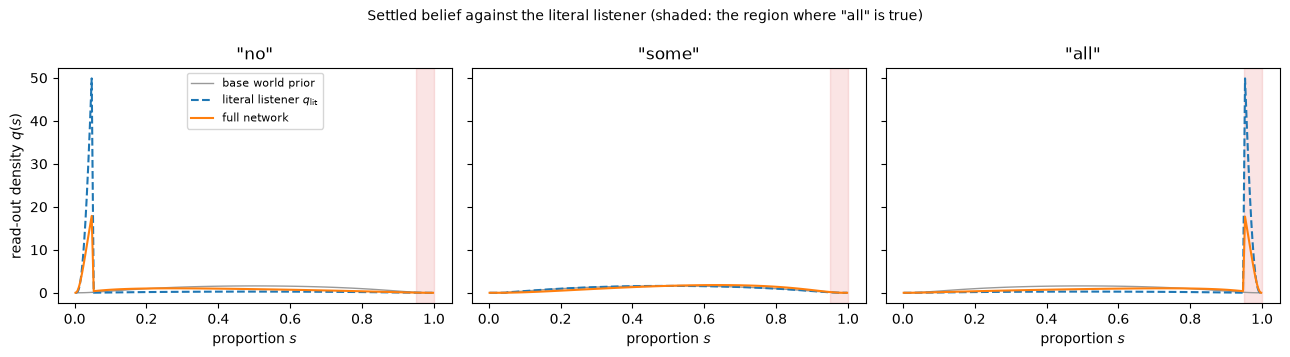

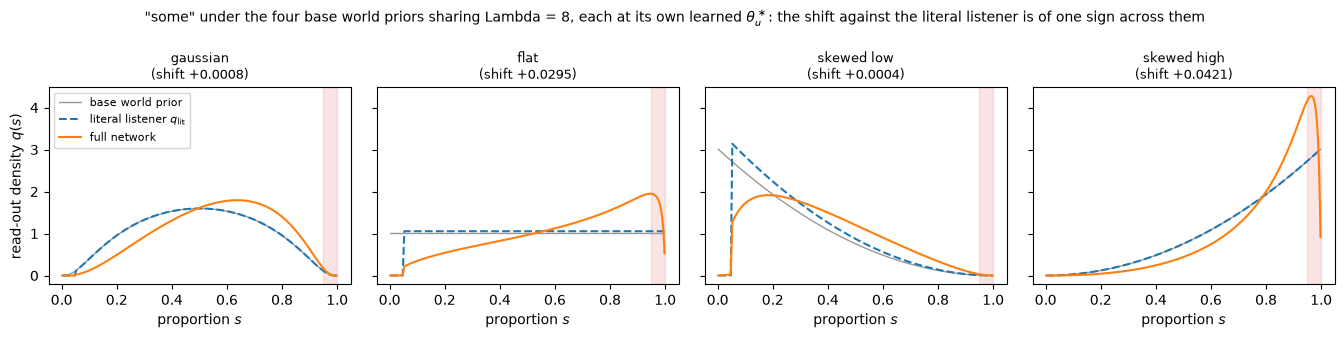

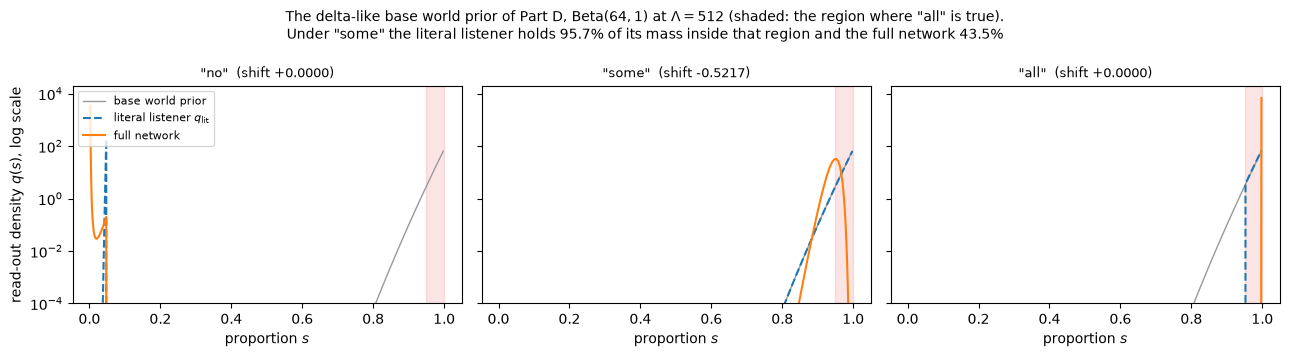

THE DELTA READ-OUT: phi_S* AT THE SETTLED STATE, BY BASE WORLD PRIOR (Bogacz Eq. 34)

  prior        theta_u                 y                     phi_u*  peak of phi_S* at s  max phi_S*  min phi_S*  q-mass, zeta > theta_L
  gaussian     theta_u* = -28.4375     no        [+0.3223, +0.4526]               0.0474       -1.04      -19.90                  0.0006
  gaussian     theta_u* = -28.4375     some      [-0.3174, +0.8572]               0.5890        3.53      -23.58                  0.0025
  gaussian     theta_u* = -28.4375     all       [-0.3174, +0.4526]               0.9526       -1.06      -19.87                  0.3740
  flat         theta_u* = 5950.6256    no        [-0.0015, +0.0001]               0.0474       -0.44       -9.01                  0.0007
  flat         theta_u* = 5950.6256    some      [+0.0015, -0.0018]               0.6726        1.17      -12.73                  0.0799
  flat         theta_u* = 5950.6256    all       [+0.0015, +0.0001]               0.9526    

  delta (all)  realizable 13.3749      no      [-15.1899, +15.4284]               0.0025      -72.58     -333.68                  0.0000


  delta (all)  realizable 13.3749      some    [+71.1166, -39.1606]               0.9468      139.18     -852.64                  0.4386


  delta (all)  realizable 13.3749      all     [+71.1166, +15.4284]               0.9975      303.41     -617.13                  1.0000
  (peak: the grid node where phi_S* is largest. The last column is Eq. (27) under the
   read-out q of Eq. (12), for comparison; the delta read-out does not use it.)

  THE PEAK OF ell_0 AGAINST THE CELL OF "all", zeta >= theta_L = 2.9444, s >= 0.9500 (Appendix A)
    prior                ell_0 peak (s)         phi_S*("some") peak (s)   at
    gaussian             0.5000 outside                  0.5890 outside   theta_u* = -28.4375
    flat                 0.5000 outside                  0.6726 outside   theta_u* = 5950.6256
    skewed low           0.2535 outside                  0.3274 outside   theta_u* = -14.5079
    skewed high          0.7465 outside                  0.8429 outside   theta_u* = 55.0081
    delta (all)          0.9852 inside                   0.9468 outside   theta_u* = 1407.7691
    delta (all)          0.9852 inside            

In [2]:
# === Code Cell E2: EVALUATION ===
#
# Code Cell 2 of main.ipynb with four checks added to Part A and nothing else
# changed. The four are Eq. (E4a) against Eq. (20)'s column form, the non-vacuity of
# m > 1, a lagged relay landing on the instantaneous fixed point, and the stability
# boundary of Eq. (E5). The other checks must report exactly what they reported in
# main.ipynb; Code Cell E3 checks that they do, by running this same sequence
# again with its output captured and diffing it against what main.ipynb stored.

# === Code Cell 2: EVALUATION, covering specification checks, demonstration,
#     and the semantic question ===
#
# Part A tests every claim the specification makes that is testable.
# Part B shows what the network does.
# Part C asks whether it produces a scalar implicature, under the criterion Text
# cell 4 Part C adopts; that cell states what the reading commits us to.
#
# Every network here carries its own LEARNED theta_u* (Eq. B2), re-learned for every
# configuration it is respawned into. A fixed theta_u appears only as a stated control.

import math
import time
import torch


# ============================================================================
# SETTLING: integrated where feasible, closed form elsewhere
# ============================================================================

# Under the timescale commitment (`fast_time_constant`), tau_error and dt scale as
# 1 / lambda_max(H), which grows as theta_u^2, and an integration takes about
# 180 lambda_max(H) Euler steps. Where theta_u* is large that is out of reach: the flat
# prior's theta_u* = 5951 puts lambda_max(H) at 3.5e7. The fixed point is not in doubt
# there, since Eqs. (15)-(16) are exact while phi_L is clamped (Sec. 8.6) and Part A
# checks `infer` against them wherever it runs. So the evaluation integrates where
# lambda_max(H) is at most FEASIBLE_STIFFNESS, about 7 s per inference, reads the
# closed form elsewhere, and says which it did.
FEASIBLE_STIFFNESS = 1.0e3


def describe_theta(net):
    """How a network's theta_u was set, for table headers."""
    kind = "learned, theta_u*" if net.theta_u_learned else "fixed control"
    return f"theta_u = {net.theta_u:.4f} ({kind})"


def settle(net, utterance, theta_u=None):
    """The settled state for one utterance: integrated if feasible, else closed form.

    Returns phi_S, phi_u, the read-out q, whether it was integrated, and the step
    count (None for the closed form)."""
    theta = net.theta_u if theta_u is None else float(theta_u)
    if net.stiffest_state_rate(theta) <= FEASIBLE_STIFFNESS:
        result = net.infer(utterance, theta_u=theta, record_history=False)
        if not result["converged"]:
            raise RuntimeError(f"{utterance!r} did not settle at theta_u = {theta:.4g}")
        return {"phi_S": result["phi_S"], "phi_u": result["phi_u"], "q": result["q"],
                "integrated": True, "steps": result["steps"]}
    phi_S, phi_u = net.closed_form_fixed_point(utterance, theta_u=theta)
    return {"phi_S": phi_S, "phi_u": phi_u, "q": net.read_out(phi_S),
            "integrated": False, "steps": None}


# ============================================================================
# A. SPECIFICATION CHECKS
# ============================================================================

def check_specification(net, *, seed=0, verbose=True):
    """Test each testable claim of the specification. Returns {claim: (ok, detail)}.

    Run at the network's own theta_u (theta_u* for the evaluation network), with the
    time constants of the timescale commitment (`fast_time_constant`)."""
    torch.manual_seed(seed)
    results = {}

    # Sec. 6 / Sec. 8.6: `infer` must reproduce the closed forms exactly, since the
    # model is linear-Gaussian while phi_L is clamped.
    worst_state = worst_utility = 0.0
    worst_identity_1 = worst_identity_2 = 0.0
    worst_monotone = math.inf
    worst_q_mass = 0.0
    runs = {}
    for utterance in UTTERANCES:
        result = net.infer(utterance)
        runs[utterance] = result
        if not result["converged"]:
            results["convergence"] = (False, f"{utterance} did not converge")
        phi_S_star, phi_u_star = net.closed_form_fixed_point(utterance)
        worst_state = max(worst_state, float((result["phi_S"] - phi_S_star).abs().max()))
        worst_utility = max(
            worst_utility, float((result["phi_u"] - phi_u_star).abs().max())
        )

        # Eq. (17): eps_S = -eps_L and eps_u = theta_u B^T W eps_S
        units = result["error_units"]
        worst_identity_1 = max(
            worst_identity_1, float((units["state"] + units["lexical"]).abs().max())
        )
        worst_identity_2 = max(
            worst_identity_2,
            float(
                (units["utility"] - net.theta_u * net.project(units["state"]))
                .abs()
                .max()
            ),
        )

        # Sec. 8.2: F is non-decreasing along the flow
        trace = [entry["free_energy"] for entry in result["history"]]
        worst_monotone = min(
            worst_monotone, min(trace[i + 1] - trace[i] for i in range(len(trace) - 1))
        )

        # Eq. (12): the read-out integrates to 1
        worst_q_mass = max(
            worst_q_mass, abs(float((net.weights * result["q"]).sum()) - 1.0)
        )

    results.setdefault("convergence", (True, "all three utterances settled"))
    results["fixed point matches Eqs. (15)-(16)"] = (
        max(worst_state, worst_utility) < 1e-8,
        f"max |phi - phi*| = {max(worst_state, worst_utility):.2e}",
    )
    results["Eq. (17) eps_S = -eps_L"] = (
        worst_identity_1 < 1e-8, f"max residual = {worst_identity_1:.2e}"
    )
    results["Eq. (17) eps_u = theta_u B^T W eps_S"] = (
        worst_identity_2 < 1e-8, f"max residual = {worst_identity_2:.2e}"
    )
    results["Sec. 8.2  F non-decreasing"] = (
        worst_monotone > -1e-9,
        f"min step = {worst_monotone:+.2e} (roundoff at the fixed point), at "
        f"tau_error = {runs['some']['tau_error']:.3e} = tau_state / (4 lambda_max(H))",
    )
    results["Eq. (12) read-out normalized"] = (
        worst_q_mass < 1e-10, f"max |1 - q-mass| = {worst_q_mass:.2e}"
    )

    # Sec. 7 / Appendix B: the locality of Eq. (20) at m > 1. The gradient is now
    # written at the descending relay, <eps_S, r> with r = B phi_u, which pools across
    # the K terminals of the one r -> eps_S projection. The form it replaces,
    # sum_j phi_u,j <eps_S, b_j>, is the same number and pools instead across m
    # synapses on m different neurons, which is the sharing Bogacz's Sec. 5 rejects
    # for Sigma. The architecture changed; the arithmetic must not have, and the
    # m > 1 case being defended must not be vacuous.
    worst_relay_gradient = 0.0
    weakest_column = math.inf
    column_report = []
    for utterance in UTTERANCES:
        result = runs[utterance]
        relay_form = float(net.theta_u_gradient(result))
        columns = net.theta_u_gradient_columns(result)
        worst_relay_gradient = max(
            worst_relay_gradient, abs(relay_form - float(columns.sum()))
        )
        weakest_column = min(weakest_column, float(columns.abs().min()))
        column_report.append(
            utterance + "=[" + ", ".join(f"{float(c):+.3f}" for c in columns) + "]"
        )
    results["Eq. (20) relay form equals column form"] = (
        worst_relay_gradient < 1e-12,
        f"max |<eps_S,r> - sum_j phi_u,j <eps_S,b_j>| = {worst_relay_gradient:.2e}",
    )
    results["Sec. 7 every basis column carries Eq. (20)"] = (
        weakest_column > 1e-3,
        "phi_u,j <eps_S,b_j> per column: " + "; ".join(column_report),
    )

    # The relay's own dynamics, tau_r r' = B phi_u - r, have fixed point r = B phi_u
    # for every tau_r, so a lagged relay must settle exactly where the instantaneous
    # one does. The lag is set from the ordering tau_relay <= tau_error, at half the
    # error units' time constant, and F must still rise monotonically along the way.
    worst_lagged = 0.0
    worst_lagged_step = math.inf
    tau_relay = 0.5 * net.fast_time_constant()
    for utterance in UTTERANCES:
        instant = runs[utterance]
        lagged = net.infer(utterance, tau_relay=tau_relay)
        if not lagged["converged"]:
            worst_lagged = math.inf
        worst_lagged = max(
            worst_lagged,
            float((instant["phi_S"] - lagged["phi_S"]).abs().max()),
            float((instant["phi_u"] - lagged["phi_u"]).abs().max()),
            float((lagged["relay"] - net.relay(lagged["phi_u"])).abs().max()),
        )
        trace = [entry["free_energy"] for entry in lagged["history"]]
        worst_lagged_step = min(
            worst_lagged_step, min(trace[i + 1] - trace[i] for i in range(len(trace) - 1))
        )
    results["Sec. 7 a lagged relay settles where the instant one does"] = (
        worst_lagged < 1e-9 and worst_lagged_step > -1e-9,
        f"max |instantaneous - lagged| = {worst_lagged:.2e} at tau_relay = tau_error / 2 "
        f"= {tau_relay:.2e}; min F step {worst_lagged_step:+.1e}",
    )

    # What the relay costs in speed. The relay is a lag inside a loop whose gain is
    # theta_u^2: two lags are stable at every gain, three are not. With slow error
    # units the error lag was the third, and the relay had to be faster than about
    # theta_u^-2 or the loop oscillated. The timescale commitment removes that: its
    # tau_error is fast enough that the loop is effectively two lags, and the spectrum
    # (`relay_loop_abscissa`, Eq. E5) is stable for every tau_relay below tau_error, so
    # the largest stable tau_relay found by bisection is tau_error itself at every
    # theta_u. The old requirement is reproduced as a control, from the spectrum
    # directly, at the tau_error = 0.1 the commitment forbids. What remains is the
    # ordering tau_relay <= tau_error, which keeps F monotone, and which inherits the
    # theta_u^-2 scaling from tau_error:
    #
    #     tau_relay <= tau_error <= tau_state / (4 lambda_max(H)).
    def spectral_boundary(theta, tau_error):
        """Largest tau_relay below tau_error at which the relay loop is stable."""
        def stable(tau_relay):
            return net.relay_loop_abscissa(theta, tau_error, tau_relay) < 0.0
        lo, hi = tau_error * 1e-9, tau_error * (1.0 - 1e-12)
        if stable(hi):
            return hi
        for _ in range(60):
            mid = math.sqrt(lo * hi)
            lo, hi = (mid, hi) if stable(mid) else (lo, mid)
        return lo

    thetas = (-20.0, net.theta_u, -40.0, -80.0)
    committed = {theta: spectral_boundary(theta, net.fast_time_constant(theta))
                 / net.fast_time_constant(theta) for theta in thetas}
    slow_errors = [theta * theta * spectral_boundary(theta, 0.1) for theta in thetas]
    results["Sec. 7 the relay need only be faster than the error units"] = (
        all(ratio > 1.0 - 1e-9 for ratio in committed.values())
        and all(1.0 < value < 1.03 for value in slow_errors)
        and slow_errors == sorted(slow_errors, reverse=True),
        "under the commitment the largest stable tau_relay / tau_error = "
        + ", ".join(f"{ratio:.4f}" for ratio in committed.values())
        + " at theta_u = " + ", ".join(f"{theta:g}" for theta in thetas)
        + "; control at tau_error = 0.1: theta_u^2 tau_crit = "
        + ", ".join(f"{value:.4f}" for value in slow_errors),
    )

    # Sec. 8.1/8.4: the Hessian is negative definite, and Sec. 8.1(ii) says so
    # for every theta_u and Lambda. Run at m = num_basis, so the form tested is
    # Eq. (22) of Sec. 8.4, which reduces to Eq. (21) at m = 1. The list of theta_u is
    # a sweep, since the claim is about every theta_u; it includes the network's own.
    worst_form = -math.inf
    for theta in [-50.0, -1.0, 0.0, 1.0, 50.0, net.theta_u]:
        for _ in range(400):
            v = torch.randn(net.num_nodes, dtype=net.dtype)
            t = torch.randn(net.num_basis, dtype=net.dtype)
            scale = math.sqrt(float(v.pow(2).sum() + t.pow(2).sum()))
            worst_form = max(
                worst_form,
                float(net.hessian_quadratic_form(v / scale, t / scale, theta_u=theta)),
            )
    results["Eq. (22) Hessian negative definite"] = (
        worst_form < 0.0, f"max over unit directions = {worst_form:+.3e}"
    )

    # Sec. 8.1(iii): phi_L enters r_L additively and so shifts the maximizer without
    # touching the Hessian. The testable consequence is about the RELAXATION RATE, not
    # the step count: phi_L moves the fixed point, so different utterances start at
    # different distances from it and reach an absolute tolerance at different times.
    # What must agree is the asymptotic rate, which is set by the eigenvalues of the
    # Hessian alone. It is read per unit time, as the least-squares slope of
    # log(max derivative) against time, since dt is set by the timescale commitment and
    # a per-step factor at small dt sits so close to 1 that a tolerance on it tests
    # nothing. The window is chosen by VALUE: from 1e6 down to 1e3 times the settling
    # tolerance, late enough for the faster modes to have died out and early enough to
    # stay above the roundoff floor, which 1/tau_error amplifies at large theta_u.
    relaxation = {}
    for utterance in UTTERANCES:
        trace = [entry["max_derivative"] for entry in runs[utterance]["history"]]
        dt_used = runs[utterance]["dt"]
        window = [(k * dt_used, math.log(value)) for k, value in enumerate(trace)
                  if 1e3 * 1e-10 <= value <= 1e6 * 1e-10]
        mean_t = sum(time for time, _ in window) / len(window)
        mean_v = sum(value for _, value in window) / len(window)
        slope = (sum((time - mean_t) * (value - mean_v) for time, value in window)
                 / sum((time - mean_t) ** 2 for time, _ in window))
        relaxation[utterance] = -slope
    rates = list(relaxation.values())
    spread = (max(rates) - min(rates)) / max(rates)
    # tolerance reflects the precision of a rate estimated off a discrete trace near
    # the roundoff floor (about 1e-6 relative at theta_u*), not the sharpness of the
    # claim; at theta_u = 1 the same estimate agrees to 1e-10.
    results["Sec. 8.1(iii) relaxation rate independent of phi_L"] = (
        spread < 1e-5,
        "rate per unit time " + ", ".join(f"{y}={r:.7f}" for y, r in relaxation.items())
        + f" (relative spread {spread:.1e})",
    )

    # Sec. 7: the analytic messages are the gradients of Eq. (13). Checked against
    # central differences at an off-equilibrium point, which is where a sign error
    # would show.
    utterance = "some"
    phi_L = net.lexical_field(utterance)
    settled = runs[utterance]
    phi_S = settled["phi_S"] + 0.3 * torch.randn_like(settled["phi_S"])
    phi_u = settled["phi_u"] + 0.3 * torch.randn_like(settled["phi_u"])
    r_lexical, r_state, r_utility = net.residuals(phi_S, phi_u, phi_L)
    step = 1e-6

    analytic_s = -(r_state / net.sigma_state) - (r_lexical / net.sigma_lexical)
    worst_gradient = 0.0
    for k in range(0, net.num_nodes, 17):
        up, down = phi_S.clone(), phi_S.clone()
        up[k] += step
        down[k] -= step
        numeric = (
            float(net.free_energy(up, phi_u, phi_L))
            - float(net.free_energy(down, phi_u, phi_L))
        ) / (2 * step * float(net.weights[k]))
        worst_gradient = max(
            worst_gradient,
            abs(numeric - float(analytic_s[k])) / (abs(float(analytic_s[k])) + 1e-9),
        )

    analytic_u = -(r_utility / net.sigma_utility) + net.theta_u * net.project(
        r_state / net.sigma_state
    )
    for k in range(net.num_basis):
        up, down = phi_u.clone(), phi_u.clone()
        up[k] += step
        down[k] -= step
        numeric = (
            float(net.free_energy(phi_S, up, phi_L))
            - float(net.free_energy(phi_S, down, phi_L))
        ) / (2 * step)
        worst_gradient = max(
            worst_gradient,
            abs(numeric - float(analytic_u[k])) / (abs(float(analytic_u[k])) + 1e-9),
        )

    analytic_theta = float(net.dot(phi_u, net.project(r_state / net.sigma_state)))
    numeric_theta = (
        float(net.free_energy(phi_S, phi_u, phi_L, theta_u=net.theta_u + step))
        - float(net.free_energy(phi_S, phi_u, phi_L, theta_u=net.theta_u - step))
    ) / (2 * step)
    worst_gradient = max(
        worst_gradient,
        abs(numeric_theta - analytic_theta) / (abs(analytic_theta) + 1e-9),
    )
    results["Sec. 7 messages are gradients of Eq. (13)"] = (
        worst_gradient < 1e-4, f"max relative error = {worst_gradient:.2e}"
    )

    # Sec. 1: the grid discretizes the integral, not the state, so the reported
    # belief must be stable under refinement. What that claims is CONVERGENCE in K,
    # which is a statement about the tail of the sequence, not about how close two
    # coarse grids happen to sit. Testing it as a 51-vs-401 gap against a fixed
    # tolerance tests the convergence RATE instead, and the rate here is set by
    # something the claim does not mention: chi_y is a step, and trapezoidal
    # quadrature on a discontinuous integrand converges at O(h) with the step's
    # position jittering against the nodes as K changes. The smooth mask of Sec. 9.2
    # is the control, being the same model with a continuous integrand, and is
    # reported beside it.
    def expectations(num_nodes, sharpness):
        probe = net.respawn(num_nodes=num_nodes, exclusion_sharpness=sharpness)
        return [
            float((probe.weights
                   * probe.read_out(probe.closed_form_fixed_point(y)[0])
                   * logistic(probe.zeta)).sum())
            for y in UTTERANCES
        ]

    ladder = [51, 101, 201, 401, 801]
    hard = {k: expectations(k, None) for k in ladder}
    smooth = {k: expectations(k, 0.1) for k in ladder}
    spread = max(abs(hard[401][i] - hard[51][i]) for i in range(len(UTTERANCES)))
    tail = max(abs(hard[801][i] - hard[401][i]) for i in range(len(UTTERANCES)))
    smooth_tail = max(abs(smooth[801][i] - smooth[401][i]) for i in range(len(UTTERANCES)))
    results["Sec. 1  K is an accuracy parameter"] = (
        tail < 5e-3,
        f"E[s] converging: |401-801| = {tail:.1e} (hard chi_y), {smooth_tail:.1e} "
        f"(smooth chi_y); coarse 51-401 spread {spread:.1e} is the O(h) step artefact",
    )

    # Sec. 8.5: F~(theta_u) = max_x F(x, theta_u) must have an interior stationary
    # point, which is exactly what mu_u = 0 destroys: there F~ climbs monotonically to
    # an asymptote and theta_u diverges. The network reads it from Eq. (B2)
    # (`learned_theta_u`); it is located here a second, independent way, by bisection
    # on the reduced gradient, and the two must agree. The bisection loses accuracy
    # at |theta_u*| above a few thousand, where the gradient flattens; at this
    # network's theta_u* it is exact to roundoff. The dynamics are checked below.
    #
    # THE SEARCH MUST COVER BOTH SIGNS. theta_u is an unconstrained real parameter:
    # Bogacz's Eqs. (25) and (56) give a gradient and no domain, and his own solution
    # theta* = u / v_p takes whichever sign the data give. Eliminating phi_S and phi_u
    # analytically (Sec. 8.6) reduces the objective to
    #
    #     F~(theta) = const - ||theta mu_u - c||^2 / (2 (sigma_u theta^2 + S)),
    #         S = sigma_L + sigma_S,        c = B^T W (ell_0 - phi_L),
    #
    # whose stationarity condition is the quadratic
    #
    #     sigma_u <mu_u,c> theta^2 + (S ||mu_u||^2 - sigma_u ||c||^2) theta
    #                                                        - S <mu_u,c> = 0.
    #
    # Its roots have product -S / sigma_u < 0, so whenever <mu_u,c> != 0 there is
    # exactly ONE root of each sign; the maximizer is the one with sign(theta*) =
    # sign(<mu_u,c>) and the other root is a minimum. So the half-line to search is
    # read off dF~/dtheta at zero, which equals <mu_u,c> / S, a positive multiple of
    # the same inner product, rather than assumed. Bracketing on theta_u > 0 alone
    # is a restriction Bogacz does not impose, and under g_S = theta_u B phi_u (with
    # ell_0 in g_L, Eq. 9) the maximizer is negative, so such a bracket reports a
    # divergence that is an artefact of the bracket and not a property of the model.
    slow = net.respawn()
    lexical = {u: slow.lexical_field(u) for u in UTTERANCES}

    def reduced_energy(theta):
        return sum(
            float(slow.free_energy(
                *slow.closed_form_fixed_point(u, theta_u=theta), lexical[u], theta_u=theta))
            for u in UTTERANCES
        ) / len(UTTERANCES)

    def reduced_gradient(theta):
        total = 0.0
        for u in UTTERANCES:
            phi_S, phi_u = slow.closed_form_fixed_point(u, theta_u=theta)
            _, r_state, _ = slow.residuals(phi_S, phi_u, lexical[u], theta_u=theta)
            total += float(slow.dot(phi_u, slow.project(r_state / slow.sigma_state)))
        return total / len(UTTERANCES)

    ascent_at_zero = reduced_gradient(0.0)
    if ascent_at_zero == 0.0:
        raise RuntimeError(
            "dF~/dtheta_u = 0 at theta_u = 0, i.e. <mu_u, c> = 0: the quadratic above "
            "degenerates and no interior maximizer exists on either half-line"
        )
    sign = 1.0 if ascent_at_zero > 0 else -1.0

    low, high = 1e-3, 1e6                      # MAGNITUDES; the sign is fixed above
    for _ in range(120):                       # geometric bisection on the gradient
        mid = math.sqrt(low * high)
        if sign * reduced_gradient(sign * mid) > 0:
            low = mid
        else:
            high = mid
    theta_star = sign * math.sqrt(low * high)
    closed_form_star = slow.learned_theta_u()
    agreement = abs(theta_star - closed_form_star) / abs(closed_form_star)
    results["Sec. 8.5  theta_u* of Eq. (B2) matches an independent bisection"] = (
        agreement < 1e-8 and (not net.theta_u_learned or net.theta_u == closed_form_star),
        f"closed form {closed_form_star:.10f}, bisection {theta_star:.10f}, "
        f"relative gap {agreement:.1e}",
    )
    margin = reduced_energy(theta_star) - reduced_energy(sign * 1e8)
    interior = (
        reduced_energy(theta_star) > reduced_energy(0.5 * theta_star)
        and reduced_energy(theta_star) > reduced_energy(2.0 * theta_star)
        and margin > 0
    )
    results["Sec. 8.5  F~ has an interior maximum in theta_u"] = (
        interior and abs(reduced_gradient(theta_star)) < 1e-6,
        f"theta_u* = {theta_star:.4f}, |dF~/dtheta_u| = {abs(reduced_gradient(theta_star)):.1e}, "
        f"margin over the asymptote = {margin:+.4f}",
    )

    # and the flow of Eq. (20) must move toward it, with F~ monotone. It starts where
    # every configuration's flow starts, theta_u(0) = 0 (`theta_u_initial`), where the
    # network is the tempered control. The roots of the quadratic above have opposite
    # signs, so zero lies between the minimum and the maximizer, on the maximizer's
    # rising side: the gradient there already points at theta_u*, and no sign has to
    # be chosen. The flow is slow near theta_u*, where F~ is shallow, so what 25
    # updates can show is direction, monotone F~ and a shrinking gradient, not arrival.
    dynamic = net.respawn()
    trace = dynamic.learn_theta_u(UTTERANCES, tau_theta=20.0, num_updates=25)
    energies = [entry["free_energy"] for entry in trace]
    worst_step = min(energies[i + 1] - energies[i] for i in range(len(energies) - 1))
    approaching = (
        trace[0]["theta_u"] == 0.0
        and abs(dynamic.theta_u - theta_star) < abs(trace[0]["theta_u"] - theta_star)
        and dynamic.theta_u * theta_star > 0
        and abs(trace[-1]["gradient"]) < abs(trace[0]["gradient"])
    )
    results["Sec. 8.5  Eq. (20) ascends toward it from theta_u = 0"] = (
        approaching and worst_step > -1e-9,
        f"theta_u {trace[0]['theta_u']:.3f} -> {dynamic.theta_u:.3f} (target {theta_star:.3f}), "
        f"|grad| {abs(trace[0]['gradient']):.3g} -> {abs(trace[-1]['gradient']):.3g}, "
        f"min dF~ step {worst_step:+.1e}",
    )

    # Sec. 9.2: a dense-scale (smooth) lexical field changes nothing structural.
    worst_dense = 0.0
    for sharpness in [0.5, 1.0, 2.0]:
        probe = net.respawn(exclusion_sharpness=sharpness)       # its own theta_u*
        for y in UTTERANCES:
            result = probe.infer(y, record_history=False)
            phi_S_star, _ = probe.closed_form_fixed_point(y)
            worst_dense = max(
                worst_dense, float((result["phi_S"] - phi_S_star).abs().max())
            )
    results["Sec. 9.2 smooth lexical field is compatible"] = (
        worst_dense < 1e-8, f"max |phi_S - phi_S*| = {worst_dense:.2e}"
    )

    if verbose:
        width = max(len(k) for k in results)
        print("SPECIFICATION CHECKS")
        print("=" * (width + 46))
        for claim, (ok, detail) in results.items():
            print(f"  {'PASS' if ok else 'FAIL'}  {claim:<{width}}  {detail}")
        print("=" * (width + 46))
        failures = sum(1 for ok, _ in results.values() if not ok)
        print(f"  {len(results) - failures}/{len(results)} passed")
        print()

    return results


# ============================================================================
# B. DEMONSTRATION
# ============================================================================

def demonstrate(net, *, verbose=True):
    """Run the network on each utterance and report the settled belief.

    Integrated where feasible (`settle`); the steps column reports the integration,
    and reads "closed" where the closed form was used instead."""
    proportion = logistic(net.zeta)
    upper_region = (net.zeta > net.theta_L).to(net.dtype)
    lower_region = (net.zeta <= -net.theta_L).to(net.dtype)

    table = {}
    for utterance in UTTERANCES:
        result = settle(net, utterance)
        q = result["q"]
        excluded = exclusion_indicator(
            utterance, net.zeta, net.theta_L, sharpness=net.exclusion_sharpness
        )
        table[utterance] = {
            "q": q,
            "expected_s": float((net.weights * q * proportion).sum()),
            "leak": float((net.weights * q * excluded).sum()),
            "upper_q_mass": float((net.weights * q * upper_region).sum()),
            "lower_q_mass": float((net.weights * q * lower_region).sum()),
            "phi_u": result["phi_u"].tolist(),
            "steps": result["steps"],
        }

    if verbose:
        print("DEMONSTRATION")
        print(f"  Lambda = {net.lexical_strength}, {describe_theta(net)}, "
              f"mu_u = {net.mu_u.tolist()}, boundary = {net.theta_L}")
        print()
        print(f"  {'utterance':<10}{'E[s]':>9}{'P(s~0)':>10}{'P(s~1)':>10}"
              f"{'leak':>10}{'steps':>9}   phi_u (tilt, width)")
        for utterance, row in table.items():
            steps = "closed" if row["steps"] is None else str(row["steps"])
            print(f"  {utterance:<10}{row['expected_s']:>9.4f}{row['lower_q_mass']:>10.4f}"
                  f"{row['upper_q_mass']:>10.4f}{row['leak']:>10.4f}{steps:>9}"
                  f"   [{row['phi_u'][0]:+.3f}, {row['phi_u'][1]:+.3f}]")
        print()
        print("  'leak' is the q-mass over the region the entry excludes;")
        print("  it goes to zero as Lambda grows, which is the Eq. (15) limit of Sec. 6.")
        print("  'steps' are Euler steps at the time constants of the timescale commitment,")
        print(f"  dt = tau_error / 2 = {0.5 * net.fast_time_constant():.2e} here.")
        print()

    return table


def lexical_strength_sweep(net, strengths=(1, 2, 4, 8, 16, 32, 64)):
    """Sec. 6: a hard support constraint is the Lambda -> infinity
    limit of Eq. (15), not a separate assumption. Leak should fall monotonically to 0.

    Each Lambda is its own configuration and carries its own theta_u*, which runs to
    1535 at Lambda = 32, so the fixed points are read in closed form (exact by
    Sec. 8.6) at every row rather than integrated at some rows and not others."""
    rows = []
    for strength in strengths:
        probe = net.respawn(lexical_strength=float(strength))
        leaks = []
        for utterance in UTTERANCES:
            q = probe.read_out(probe.closed_form_fixed_point(utterance)[0])
            excluded = exclusion_indicator(
                utterance, probe.zeta, probe.theta_L,
                sharpness=probe.exclusion_sharpness,
            )
            leaks.append(float((probe.weights * q * excluded).sum()))
        rows.append((float(strength), max(leaks), probe.theta_u))

    print("LAMBDA -> INFINITY RECOVERS THE HARD MASK (Sec. 6)")
    print("  (closed form, each Lambda at its own learned theta_u*)")
    print(f"  {'Lambda':>8}{'theta_u*':>12}{'max leak':>12}")
    for strength, leak, star in rows:
        print(f"  {strength:>8.0f}{star:>12.3f}{leak:>12.6f}")
    monotone = all(rows[i + 1][1] <= rows[i][1] + 1e-12 for i in range(len(rows) - 1))
    print(f"  monotone decreasing: {monotone};  leak at Lambda={rows[-1][0]:.0f} "
          f"is {rows[-1][1]:.2e}")
    print()
    return rows


# ============================================================================
# C. THE SEMANTIC QUESTION: IS THERE A SCALAR IMPLICATURE?
# ============================================================================

def scalar_implicature_probe(net, *, verbose=True):
    """Compare the settled belief against the literal listener.

    The baseline is q_lit, the untempered literal posterior of
    `literal_fixed_point`: phi_S = ell_0 - phi_L, the world prior restricted by the
    lexical entry and nothing else. The shift is measured against it.

    The theta_u = 0 belief is reported beside it as a secondary control. It is the
    same literal posterior tempered by one half (see `literal_fixed_point`), so it
    holds the temperature of the full network fixed while severing the utility level;
    q_lit holds the definition fixed instead. The two differ, and Text cell 4 Part D
    states by how much.

    A scalar implicature for "some" would move q-mass AWAY from the region where
    "all" is true. The measured quantity is therefore the change in P(s in all-region)
    between q_lit and the full network, the shift of Eq. (37), and Text cell 4 Part C's
    criterion is the conjunction of two conditions: the shift for "some" is NEGATIVE
    (first), and the full network's P(all-region | "some") is below 1/2 (second).
    """
    upper_region = (net.zeta > net.theta_L).to(net.dtype)
    proportion = logistic(net.zeta)

    rows = {}
    for utterance in UTTERANCES:
        baseline = net.read_out(net.literal_fixed_point(utterance))
        tempered = net.infer(utterance, theta_u=0.0, record_history=False)["q"]
        full = settle(net, utterance)["q"]
        rows[utterance] = {
            "tempered_upper": float((net.weights * tempered * upper_region).sum()),
            "baseline_upper": float((net.weights * baseline * upper_region).sum()),
            "full_upper": float((net.weights * full * upper_region).sum()),
            "baseline_expected_s": float((net.weights * baseline * proportion).sum()),
            "full_expected_s": float((net.weights * full * proportion).sum()),
            "baseline_q": baseline,
            "full_q": full,
        }
        rows[utterance]["shift"] = (
            rows[utterance]["full_upper"] - rows[utterance]["baseline_upper"]
        )

    if verbose:
        print("SCALAR IMPLICATURE PROBE")
        print(f"  full network: {describe_theta(net)}")
        print("  baseline: q_lit, the untempered literal posterior (phi_S = ell_0 - phi_L)")
        print("  also shown: the theta_u = 0 control, that posterior tempered by 1/2")
        print()
        print(f"  {'utterance':<10}{'E[s] base':>11}{'E[s] full':>11}"
              f"{'P(all) base':>13}{'P(all) full':>13}{'shift':>10}"
              f"{'P(all) th_u=0':>15}")
        for utterance, row in rows.items():
            print(f"  {utterance:<10}{row['baseline_expected_s']:>11.4f}"
                  f"{row['full_expected_s']:>11.4f}{row['baseline_upper']:>13.4f}"
                  f"{row['full_upper']:>13.4f}{row['shift']:>+10.4f}"
                  f"{row['tempered_upper']:>15.4f}")
        print()
        shift = rows["some"]["shift"]
        upper = rows["some"]["full_upper"]
        first, second = shift < 0, upper < 0.5
        print(f"  first condition, shift for \"some\" < 0:        "
              f"{'met' if first else 'NOT met'} ({shift:+.4f})")
        print(f"  second condition, P(all-region | \"some\") < 1/2: "
              f"{'met' if second else 'NOT met'} ({upper:.4f})")
        print(f"  Under the criterion of Text cell 4 Part C, the conjunction, the "
              f"criterion is {'met' if first and second else 'NOT met'}:")
        print(f"  under \"some\" the settled belief holds {abs(shift):.4f} "
              f"{'less' if shift < 0 else 'MORE'} all-region q-mass than q_lit.")
        print("  Whether the criterion is met is a measurement; what meeting it commits")
        print("  the model to is argued in Text cell 4 Part C, not here. Note that the")
        print("  same criterion is met by other utterances too (see the shift column")
        print("  above), and that its sign is prior-dependent (Part D).")
        print()

    return rows


def theta_u_learning_probe(net, *, tau_theta=20.0, num_updates=60):
    """Sec. 8.5: integrate Eq. (20), tau_theta * d(theta_u)/dt = dF/d(theta_u).

    There is no learning rate: tau_theta is a time constant of the same kind as
    tau_error and tau_state, and the model's one timescale ordering runs
    tau_error <= tau_state / (4 lambda_max(H)) and tau_state << tau_theta. It sets the
    rate, not the fixed point.

    The flow starts at theta_u(0) = 0 (`theta_u_initial`), the one start every
    configuration shares. There the network is the TEMPERED control, not the literal
    listener, which would also need sigma_S -> infinity. The gradient at zero is
    <mu_u, sum_y c_y> / S, nonzero, and has the sign of theta_u* (Appendix B), so the
    flow leaves zero toward it without any sign being chosen.

    Requires <mu_u, sum_y c_y> != 0 (Appendix B); mu_u != 0 (Sec. 3) is necessary but
    not sufficient. Otherwise F~ has no stationary point and theta_u diverges, which
    is Bogacz's Eq. (25) at v_p = 0, not a departure from it.
    """
    net = net.respawn()
    star = net.learned_theta_u()
    trace = net.learn_theta_u(UTTERANCES, tau_theta=tau_theta, num_updates=num_updates)
    energies = [entry["free_energy"] for entry in trace]
    monotone = all(
        energies[i + 1] >= energies[i] - 1e-9 for i in range(len(energies) - 1)
    )
    upper = (net.zeta > net.theta_L).to(net.dtype)
    literal_upper = float(
        (net.weights * net.read_out(net.literal_fixed_point("some")) * upper).sum())

    def shift_for_some(theta):
        belief = net.read_out(net.closed_form_fixed_point("some", theta_u=theta)[0])
        return float((net.weights * belief * upper).sum()) - literal_upper

    at_start, at_end, at_star = (shift_for_some(theta)
                                 for theta in (trace[0]["theta_u"], net.theta_u, star))
    print("SLOW PARAMETER (Eq. 20, Sec. 8.5)")
    print(f"  mu_u = {net.mu_u.tolist()}  (must be nonzero)")
    print(f"  start: theta_u(0) = {trace[0]['theta_u']:.4f}, the tempered control; "
          f"dF~/dtheta_u there = {trace[0]['gradient']:+.4f}")
    print(f"  theta_u: {trace[0]['theta_u']:.4f} -> {net.theta_u:.6f} over {num_updates} "
          f"updates at tau_theta = {tau_theta:g};  theta_u* = {star:.4f} (Eq. B2)")
    print(f"  F~ increased monotonically: {monotone}")
    print(f"  final dF~/dtheta_u = {trace[-1]['gradient']:+.3e}"
          f"  ({'settled' if abs(trace[-1]['gradient']) < 1e-3 else 'still ascending'})")
    print("  The flow is slow near the optimum because F~ is shallow there; the target")
    print("  is the stationary point Part A locates in closed form, not this endpoint.")
    print()
    print(f"  shift for \"some\" (Eq. 37, against q_lit): {at_start:+.4f} at the start, "
          f"{at_end:+.4f} at the endpoint, {at_star:+.4f} at theta_u*")
    toward = at_star < at_start
    reached = at_star < 0
    print(f"  Ascending F~ moves the shift {'DOWN, toward' if toward else 'UP, away from'} "
          f"the first condition of Text cell 4 Part C, and "
          f"{'crosses zero' if reached else 'does not reach it'} at theta_u*.")
    print("  Eq. (13) contains no term rewarding informativity, so this is not F pursuing")
    print("  the criterion: raising |theta_u| amplifies the span(B) component of")
    print("  (ell_0 - phi_L), and the sign of the shift is set by where those directions")
    print("  put mass relative to the all-region. See `theta_u_dependence` below.")
    print()
    return net, trace


def theta_u_stationary_point(net):
    """theta_u* for this configuration, in closed form (Eq. B2).

    Delegates to the network (`learned_theta_u`), so it holds whether the network
    carries theta_u* or a fixed control value. Part A cross-checks it against an
    independent bisection on the reduced gradient."""
    return net.learned_theta_u()


def theta_u_dependence(net, *, verbose=True):
    """Every headline number in this cell, recomputed across theta_u: a CONTROL.

    The rest of the evaluation is reported at the learned theta_u*, which is NEGATIVE
    here (Appendix B). This probe holds theta_u fixed at chosen values so that the
    dependence of each number on theta_u, and on its sign, is visible rather than
    assumed. Four columns: the tempered control (theta_u = 0, which is also where the
    flow of Eq. (20) starts), +1 and -1, and the learned theta_u*.

    The shift row is Eq. (37), against q_lit, exactly as everywhere else in the
    notebook; the tempered-control column therefore shows what the theta_u = 0
    tempering does on its own rather than a column of zeros.

    Read it for two things. Which quantities depend on theta_u at all, and which of
    those depend on its SIGN: the utility level reaches phi_S through theta_u * B and
    the fixed point through theta_u^2 * G, so quantities dominated by the quadratic
    term are near-identical at +theta and -theta while the mu_u-carried linear term
    is what breaks the symmetry.
    """
    star = theta_u_stationary_point(net)
    settings = [("tempered (0)", 0.0), ("+1", 1.0),
                ("-1", -1.0), ("learned", star)]
    proportion = logistic(net.zeta)
    upper = (net.zeta > net.theta_L).to(net.dtype)

    table = {}
    for label, theta in settings:
        column = {}
        for y in UTTERANCES:
            field = net.closed_form_fixed_point(y, theta_u=theta)[0]
            belief = net.read_out(field)
            base = net.read_out(net.literal_fixed_point(y))
            excluded = exclusion_indicator(
                y, net.zeta, net.theta_L, sharpness=net.exclusion_sharpness
            )
            column[y] = {
                "expected_s": float((net.weights * belief * proportion).sum()),
                "upper": float((net.weights * belief * upper).sum()),
                "leak": float((net.weights * belief * excluded).sum()),
                "shift": float((net.weights * belief * upper).sum())
                         - float((net.weights * base * upper).sum()),
            }
        contrast = (net.closed_form_fixed_point("all", theta_u=theta)[0]
                    - net.closed_form_fixed_point("some", theta_u=theta)[0])
        column["contrast"] = float(net.squared_norm(contrast)) ** 0.5
        table[label] = column

    if verbose:
        print("THETA_U DEPENDENCE OF THE REPORTED QUANTITIES")
        print(f"  theta_u* = {star:.4f} (closed form, Appendix B); the rest of this cell")
        print(f"  reports it. The other three columns hold theta_u fixed, as a control.")
        print()
        for name, key, fmt in [("E[s]", "expected_s", "{:>15.4f}"),
                               ("P(all-region)", "upper", "{:>15.4f}"),
                               ("shift vs q_lit (37)", "shift", "{:>+15.4f}"),
                               ("leak", "leak", "{:>15.2e}")]:
            print(f"  {name}")
            print(f"    {'utterance':<12}" + "".join(f"{lab:>15}" for lab, _ in settings))
            for y in UTTERANCES:
                print(f"    {y:<12}"
                      + "".join(fmt.format(table[lab][y][key]) for lab, _ in settings))
            print()
        print(f"    {'||contrast||':<12}"
              + "".join(f"{table[lab]['contrast']:>15.4f}" for lab, _ in settings))
        print("    (all - some, in the quadrature norm; it GROWS with |theta_u|, so the")
        print("     utility level does move contrasts, unlike mu_u and ell_0.)")
        print()
        symmetric = max(
            abs(table["+1"][y][key] - table["-1"][y][key])
            for y in UTTERANCES for key in ("expected_s", "upper")
        )
        print(f"  theta_u = +1 against theta_u = -1: largest difference {symmetric:.4f}.")
        print("  That is not small, and it is worth knowing WHERE it is large. phi_u*")
        print("  carries a term linear in theta_u (through mu_u) and one quadratic in it")
        print("  (through G); only the linear one changes under theta_u -> -theta_u, and")
        print("  it is relatively largest when |theta_u| is of order 1:")
        print()
        print(f"    {'|theta_u|':>12}{'max dE[s]':>12}{'max dP(all)':>14}")
        for magnitude in (0.5, 1.0, 2.0, 5.0, 10.0, abs(star), 100.0):
            gaps = [[], []]
            for y in UTTERANCES:
                plus = net.read_out(net.closed_form_fixed_point(y, theta_u=magnitude)[0])
                minus = net.read_out(net.closed_form_fixed_point(y, theta_u=-magnitude)[0])
                gaps[0].append(abs(float((net.weights * plus * proportion).sum())
                                   - float((net.weights * minus * proportion).sum())))
                gaps[1].append(abs(float((net.weights * plus * upper).sum())
                                   - float((net.weights * minus * upper).sum())))
            print(f"    {magnitude:>12.4f}{max(gaps[0]):>12.4f}{max(gaps[1]):>14.4f}")
        print()
        print("  The sign therefore matters most at |theta_u| of order 1 and progressively")
        print("  less toward |theta_u*|, where the quadratic term dominates and the two")
        print("  signs converge. The numbers this cell reports are read at theta_u*.")
        print()

    return table, star



# ============================================================================
# D. BASE WORLD PRIOR
# ============================================================================

# The delta-like row. Part D's other four priors are all diffuse over the scale, so
# none of them puts the criterion under any pressure: hearing "some" under a prior
# that is already spread out, there is little all-region mass to move away from. The
# sharp case is the one worth testing, and it is the case Code Cell 4 is built around.
#
# A literal delta at s = 1 is not representable, since s lies in the OPEN interval, so
# zeta = logit(1) is off the grid and ell_0 = log p_0 would be -infinity almost
# everywhere. Beta(alpha, 1) is the limit family that approaches it (Text cell 6).
#
#   alpha = 64 puts the mode in zeta at log(alpha) = 4.16, well inside the all-region
#   (zeta > theta_L = 2.9444) and well clear of the grid ceiling, which Text cell 6
#   warns sets in above alpha ~ 300; it carries 95.7% of its prior mass in the
#   all-region and only 0.95% on the top node.
#
#   Lambda must then be raised to match, or the prior simply overrides the lexicon and
#   the sweep measures the override rather than the criterion. Eq. (41) puts the
#   override threshold at Lambda_crit ~ alpha * log(2n) = 64 * 2.9957 = 192. Taking
#   Lambda = 8 alpha = 512, about 2.7x that, drives every leak below 1e-70: the entry
#   holds against the prior, which is the precondition for the probe to mean anything.
DELTA_ALL_ALPHA = 64.0
DELTA_ALL_LAMBDA = 8.0 * DELTA_ALL_ALPHA          # = 512, about 2.7 x Lambda_crit


def part_d_priors():
    """The rows Part D sweeps: the four base world priors, and the delta-like row,
    which carries its own Lambda. Shared with the realizability block below, so the
    two report the same configurations."""
    return {
        **BASE_WORLD_PRIORS,
        "delta (all)": (
            beta_world_prior(DELTA_ALL_ALPHA, 1.0),
            {"lexical_strength": DELTA_ALL_LAMBDA},
        ),
    }


def base_prior_sweep(net, priors=None, *, verbose=True):
    """Repeat the demonstration and the implicature probe under each base world prior.

    ell_0 is a fixed quantity (Sec. 3), so changing it moves the maximizer of Eq. (13)
    and, through c_y, the learned theta_u* each prior carries. It touches nothing in
    Sec. 8: by Eq. (22) the Hessian involves theta_u but not ell_0, and every
    convergence result holds at every theta_u (Sec. 8.1(ii)), so the closed forms stay
    exact. What theta_u* does change is the stiffness of the fast subsystem, so the
    dynamics are integrated only where that is feasible (`settle`) and the table says
    where. What the sweep tests is semantic, not numerical: whether the conclusion of
    Part C is an artefact of one prior.

    The flat condition is a literal Uniform(0, 1) over the proportion, not a
    low-precision Gaussian; see `uniform_world_prior` for why the two differ.

    A prior may be given either as a log-density or as a (log_density, overrides) pair,
    the overrides passed on to `respawn`. That is how the delta-like row carries its own
    Lambda: its whole point is a prior sharp enough to need one.
    """
    priors = priors or part_d_priors()
    proportion = logistic(net.zeta)
    upper_region = (net.zeta > net.theta_L).to(net.dtype)

    rows = {}
    for name, specification in priors.items():
        prior, overrides = (
            specification if isinstance(specification, tuple) else (specification, {})
        )
        probe = net.respawn(base_prior=prior, **overrides)
        prior_density = torch.exp(probe.base_log_prior)
        entry = {
            "description": probe.base_prior_description,
            "lexical_strength": probe.lexical_strength,
            "theta_u": probe.theta_u,
            "prior_expected_s": float((probe.weights * prior_density * proportion).sum()),
            "prior_upper_mass": float((probe.weights * prior_density * upper_region).sum()),
            "utterances": {},
            "network": probe,
        }
        for y in UTTERANCES:
            settled = settle(probe, y)
            baseline = probe.read_out(probe.literal_fixed_point(y))
            tempered = probe.infer(y, theta_u=0.0, record_history=False)["q"]
            full = settled["q"]
            excluded = exclusion_indicator(
                y, probe.zeta, probe.theta_L, sharpness=probe.exclusion_sharpness
            )
            entry["utterances"][y] = {
                "expected_s": float((probe.weights * full * proportion).sum()),
                "baseline_upper": float((probe.weights * baseline * upper_region).sum()),
                "tempered_upper": float((probe.weights * tempered * upper_region).sum()),
                "full_upper": float((probe.weights * full * upper_region).sum()),
                "leak": float((probe.weights * full * excluded).sum()),
                "integrated": settled["integrated"],
                "closed_form_error": (
                    float((settled["phi_S"] - probe.closed_form_fixed_point(y)[0])
                          .abs().max())
                    if settled["integrated"] else None
                ),
                "baseline_q": baseline,
                "full_q": full,
            }
            entry["utterances"][y]["shift"] = (
                entry["utterances"][y]["full_upper"]
                - entry["utterances"][y]["baseline_upper"]
            )
        rows[name] = entry

    # The spike at the right edge of the flat and Beta(3,1) panels is a property of the
    # PLOTTING coordinate: the figures draw a density in s, dividing by ds/dzeta, which is
    # 1/405 at the top node. The modes below are read in zeta, where the grid is uniform.
    spike = {}
    for name in ("flat", "skewed high"):
        if name not in rows:
            continue
        probe = rows[name]["network"]
        entry = rows[name]["utterances"]["some"]
        spike[name] = {}
        for label, field in (("q_lit", entry["baseline_q"]), ("full", entry["full_q"])):
            mode = int(torch.argmax(field))
            spike[name][label] = {
                "s": float(proportion[mode]),
                "density": float(field[mode]),
                "top_node": float(field[-1]),
            }

    if verbose:
        print("BASE WORLD PRIOR SWEEP")
        print()
        print(f"  {'prior':<13}{'description':<43}{'Lambda':>8}{'theta_u*':>12}"
              f"{'E[s] prior':>11}{'P0(all)':>9}{'  E[s] | no    some    all':<28}")
        for name, entry in rows.items():
            means = "  ".join(
                f"{entry['utterances'][y]['expected_s']:.3f}" for y in UTTERANCES
            )
            print(f"  {name:<13}{entry['description']:<43}{entry['lexical_strength']:>8.0f}"
                  f"{entry['theta_u']:>12.4f}"
                  f"{entry['prior_expected_s']:>11.4f}{entry['prior_upper_mass']:>9.4f}"
                  f"         {means}")
        print("  (each prior at its own learned theta_u*)")
        print()
        print("  implicature shift, P(all-region) full minus q_lit, the literal listener")
        print("  (a scalar implicature for \"some\" requires a NEGATIVE shift)")
        print()
        print(f"  {'prior':<13}" + "".join(f"{y:>12}" for y in UTTERANCES)
              + f"{'max leak':>12}{'P(all|some)':>13}{'max |phi_S - phi_S*|':>24}")
        for name, entry in rows.items():
            shifts = "".join(
                f"{entry['utterances'][y]['shift']:>+12.4f}" for y in UTTERANCES
            )
            errors = [entry["utterances"][y]["closed_form_error"] for y in UTTERANCES]
            worst = ("closed form (stiff)" if None in errors
                     else f"{max(errors):.1e}")
            leak = max(entry["utterances"][y]["leak"] for y in UTTERANCES)
            print(f"  {name:<13}{shifts}{leak:>12.1e}"
                  f"{entry['utterances']['some']['full_upper']:>13.4f}{worst:>24}")
        print(f"  (the last column compares the integrated fixed point with Eqs. (15)-(16);")
        print(f"   rows marked closed form have lambda_max(H) above {FEASIBLE_STIFFNESS:.0e},")
        print(f"   where integration under the timescale commitment is not affordable)")
        print()
        first = [name for name, entry in rows.items()
                 if entry["utterances"]["some"]["shift"] < 0]
        both = [name for name in first
                if rows[name]["utterances"]["some"]["full_upper"] < 0.5]
        # the split Text cell 4 Part D reads: the theta_u = 0 control against q_lit is
        # the TEMPERING, and the rest of the shift is the utility level's own doing.
        print("  the \"some\" shift split into tempering (the theta_u = 0 control against")
        print("  q_lit) and the utility level's own contribution (the remainder):")
        print(f"  {'prior':<13}{'shift':>10}{'tempering':>12}{'utility':>10}")
        for name, entry in rows.items():
            row = entry["utterances"]["some"]
            tempering = row["tempered_upper"] - row["baseline_upper"]
            print(f"  {name:<13}{row['shift']:>+10.4f}{tempering:>+12.4f}"
                  f"{row['shift'] - tempering:>+10.4f}")
        print()
        print(f"  First condition (shift for \"some\" < 0) met under {len(first)} of "
              f"{len(rows)} priors: " + (", ".join(first) if first else "none") + ".")
        print(f"  Conjunction (also P(all-region | \"some\") < 1/2) met under {len(both)}: "
              + (", ".join(both) if both else "none") + ".")
        print("  Whether it is met is therefore NOT a property of the model alone; it")
        print("  depends on the prior the model is run against, which is a fact about the")
        print("  criterion as much as about the model. Text cell 4 Part C reads this.")
        print()

        # === what ell_0-invariance survives under learning ===
        # phi_S* is affine in ell_0 with an utterance-independent coefficient, so at a
        # SHARED theta_u the contrasts between utterances are exactly ell_0-invariant.
        # The coefficient depends on theta_u, and ell_0 moves theta_u* through c_y, so
        # under learning the invariance no longer transfers across the rows of a sweep.
        # Lambda is held at this network's own for every prior here, the delta row's
        # included: the comparison is across ell_0 alone, and phi_L must not move with it.
        contrasts = {}
        for key in ("fixed", "learned"):
            fields = []
            for specification in (priors or part_d_priors()).values():
                prior = (specification[0] if isinstance(specification, tuple)
                         else specification)
                probe = net.respawn(base_prior=prior)
                theta = 1.0 if key == "fixed" else None
                settled = {y: probe.closed_form_fixed_point(y, theta_u=theta)[0]
                           for y in UTTERANCES}
                fields.append((settled["all"] - settled["some"],
                               settled["no"] - settled["some"]))
            contrasts[key] = max(
                max(float((a - fields[0][0]).abs().max()),
                    float((b - fields[0][1]).abs().max()))
                for a, b in fields
            )
        print(f"  ell_0-invariance of the phi_S contrasts across these five priors, all at "
              f"Lambda = {net.lexical_strength:.0f}:")
        print(f"    at a shared theta_u = 1 (a control): {contrasts['fixed']:.1e}")
        print(f"    at each prior's own learned theta_u*: {contrasts['learned']:.4f}")
        print("  (exact at a shared theta_u; under learning ell_0 also moves theta_u*,")
        print("   so what is invariant is the map at fixed theta_u, not the row.)")
        print()

        # === is it the prior or the raised Lambda? a control for Part C ===
        raised = net.respawn(lexical_strength=DELTA_ALL_LAMBDA)
        belief = raised.read_out(raised.closed_form_fixed_point("some")[0])
        literal = raised.read_out(raised.literal_fixed_point("some"))
        shifted = float((raised.weights * belief * upper_region).sum()
                        - (raised.weights * literal * upper_region).sum())
        print(f"  the default Gaussian prior at the delta row's Lambda = {DELTA_ALL_LAMBDA:.0f}: "
              f"theta_u* = {raised.theta_u:.2f}, shift for \"some\" = {shifted:+.4f},")
        print(f"  against {rows['gaussian']['utterances']['some']['shift']:+.4f} at "
              f"Lambda = {net.lexical_strength:.0f}. Raising Lambda alone moves the shift")
        print("  AWAY from the criterion, so the delta row's result is the prior's doing")
        print("  and not its Lambda's (Text cell 4 Part C).")
        print()

        # === the spike at the right edge of two panels ===
        if spike:
            print("  THE RIGHT-EDGE SPIKE in the \"some\" panels of the flat and Beta(3,1)")
            print("  rows, read in zeta, where the grid is uniform (the figures draw a")
            print("  density in s, dividing by ds/dzeta, which is 1/405 at the top node):")
            print(f"    {'prior':<13}{'belief':<8}{'mode (s)':>10}{'density there':>15}"
                  f"{'density at top node':>21}")
            for name, entry in spike.items():
                for label, values in entry.items():
                    print(f"    {name:<13}{label:<8}{values['s']:>10.2f}"
                          f"{values['density']:>15.4f}{values['top_node']:>21.4f}")
            print()

        # === the delta-like row, and the headroom that makes it readable ===
        if "delta (all)" in rows:
            entry = rows["delta (all)"]
            print("  THE DELTA-LIKE ROW. This is the case the criterion is under the most")
            print("  pressure in: the prior already puts %.1f%% of its mass in the all-region,"
                  % (100 * entry["prior_upper_mass"]))
            print("  so the literal listener, given \"some\", an entry that does NOT")
            print("  exclude the all-region, stays there. Leak stays below")
            print("  %.0e, so the lexicon is holding and the probe is measuring the utility"
                  % max(entry["utterances"][y]["leak"] for y in UTTERANCES))
            print("  level rather than the prior overriding the entry.")
            print()
            print(f"    {'utterance':<10}{'P(all) base':>13}{'P(all) full':>13}{'shift':>10}"
                  f"{'room to fall':>14}{'room to rise':>14}")
            for y in UTTERANCES:
                row = entry["utterances"][y]
                print(f"    {y:<10}{row['baseline_upper']:>13.6f}{row['full_upper']:>13.6f}"
                      f"{row['shift']:>+10.4f}{row['baseline_upper']:>14.2e}"
                      f"{1.0 - row['baseline_upper']:>14.2e}")
            print()
            some_row, all_row = entry["utterances"]["some"], entry["utterances"]["all"]
            shed_some = 1.0 - some_row["full_upper"] / some_row["baseline_upper"]
            print("  READ THE HEADROOM BEFORE THE SHIFTS. \"no\" has essentially no")
            print("  all-region mass to lose and \"all\" essentially none to gain, so their")
            print("  zeros are saturation, not restraint; only \"some\" is free to move in")
            print("  both directions, and it is the one that moves. What is NOT saturation")
            print(f"  is that \"all\" keeps its all-region mass (it moves by {all_row['shift']:+.1e})")
            print(f"  while \"some\" sheds {shed_some:.1%} of its own: both had room to fall, and only")
            print("  one fell. That difference is the even-parity (width) coordinate of their")
            print("  lexical projections, which is the one place the two entries differ.")
            print()

            # === the mechanism Text cell 4 Part C reads off this row (Eqs. 23-24) ===
            probe = entry["network"]
            couplings = {y: probe.project(probe.base_log_prior - probe.lexical_field(y))
                         for y in ("some", "all")}

            def eq23_gap(model):
                """max |phi_S*(theta) - phi_S*(0) - (sigma_L theta / S) B phi_u*| at theta_u*."""
                share = model.sigma_lexical / (model.sigma_lexical + model.sigma_state)
                worst = 0.0
                for y in UTTERANCES:
                    phi_S, phi_u = model.closed_form_fixed_point(y)
                    phi_S_zero = model.closed_form_fixed_point(y, theta_u=0.0)[0]
                    worst = max(worst, float((phi_S - phi_S_zero - share * model.theta_u
                                              * torch.mv(model.basis, phi_u)).abs().max()))
                return worst

            field = probe.base_log_prior - probe.lexical_field("some")
            limit = 0.5 * field + 0.5 * torch.mv(probe.basis, probe.project(field))

            def shift_at(belief):
                return (float((probe.weights * belief * upper_region).sum())
                        - some_row["baseline_upper"])

            print("  THE MECHANISM (Text cell 4 Part C, Eqs. 23-24), on this row")
            print(f"    the prior's mode in zeta sits at log(alpha) = {math.log(DELTA_ALL_ALPHA):.2f}")
            print("    c_y = B^T W (ell_0 - phi_L), as (odd tilt, even width): "
                  + "; ".join(f"{y} [{float(c[0]):+.2f}, {float(c[1]):+.2f}]"
                              for y, c in couplings.items()))
            print(f"    Eq. (23) holds to {eq23_gap(net):.1e} at the Gaussian theta_u* and to "
                  f"{eq23_gap(probe):.1e} at this row's")
            print(f"    Eq. (24)'s limit gives a shift for \"some\" of "
                  f"{shift_at(probe.read_out(limit)):+.4f}; this row's theta_u* = "
                  f"{probe.theta_u:.2f} gives {some_row['shift']:+.4f}")
            sweep = (-1e7, -1e3, -1e2, -10.0, -1.0, -0.1, -1e-8,
                     0.0, 1e-8, 0.1, 1.0, 10.0, 1e2, 1e3, 1e7)
            shifts = {theta: shift_at(probe.read_out(
                probe.closed_form_fixed_point("some", theta_u=theta)[0])) for theta in sweep}
            print("    shift for \"some\" at fixed theta_u, a control:")
            for part in (sweep[:7], sweep[7:]):
                print("      " + "  ".join(f"{theta:g}: {shifts[theta]:+.4f}" for theta in part))
            nonzero = [value for theta, value in shifts.items() if theta != 0.0]
            print(f"    negative at every theta_u != 0 above: {all(value < 0 for value in nonzero)}; "
                  f"least negative {max(nonzero):+.4f}, most negative {min(nonzero):+.4f}")
            print()

    for name, entry in rows.items():
        entry["spike"] = spike.get(name)
    return rows


# ============================================================================
# REALIZABILITY: HOW MUCH OF theta_u* THE CRITERION NEEDS
# ============================================================================
#
# Part D reads the criterion at each prior's learned theta_u*, and under the delta-like
# prior that is theta_u* = 1408, where lambda_max(H) = 2.0e6 and one inference is hours:
# the row is exact by Sec. 8.6 but not integrated. That invites the wrong inference,
# that the implicature is the thing costing hours. It is not, and the two are separable:
#
#   the THRESHOLD, the least |theta_u| at which the conjunction of Text cell 4 Part C
#   holds, by bisection on the ray from 0 to theta_u*, with a check that it then holds
#   along the whole of that ray;
#
#   the ARRIVAL, how many updates of Eq. (20) from theta_u(0) = 0 carry the flow past
#   the threshold.
#
# The block ends with one both-conditions configuration run end to end with nothing in
# closed form: Eq. (20) integrated for those updates, with the fast subsystem integrated
# inside every one of them, then Eqs. (18)-(19) integrated at the theta_u they reach,
# and the conjunction read off that integrated fixed point.
#
# Seconds here are wall clock on the machine that ran the notebook, and stand in for two
# machine-independent quantities the table gives beside them: the Euler steps an
# inference takes, and the separation 4 lambda_max(H) that the timescale commitment
# demands between the error and the state units. Neither is a cost the process being
# modelled could plausibly pay, at the cheap end of the range or the expensive one. That
# is the complexity issue raised in the background outline about a hypothesized
# alternative representation level. That level is not implemented here, so this cell
# measures and does not argue; see the outline for the discussion.


def criterion_for_some(net, theta_u=None, *, belief=None):
    """Text cell 4 Part C's two conditions for "some", as one record.

    shift = P(all-region | "some") - P_lit(all-region | "some")  (Eq. 37), and
    upper = P(all-region | "some"); the conjunction is shift < 0 AND upper < 1/2.
    Passing `belief` scores an INTEGRATED read-out with the same code that scores the
    closed form, so the run below is compared against the table on equal terms."""
    upper_region = (net.zeta > net.theta_L).to(net.dtype)
    literal_upper = float(
        (net.weights * net.read_out(net.literal_fixed_point("some")) * upper_region).sum()
    )
    if belief is None:
        belief = net.read_out(net.closed_form_fixed_point("some", theta_u=theta_u)[0])
    upper = float((net.weights * belief * upper_region).sum())
    return {"shift": upper - literal_upper, "upper": upper,
            "both": (upper - literal_upper < 0.0) and (upper < 0.5)}


def criterion_threshold(net, *, bisections=60, ray_checks=200):
    """The least |theta_u| on the ray 0 -> theta_u* at which BOTH conditions hold.

    Nothing proved here makes the conjunction monotone in theta_u, so the bisection is
    followed by a check at `ray_checks` points between the threshold and theta_u*: the
    threshold is reported together with the answer to "and does it hold from there on".
    Returns None where the conjunction fails at theta_u* itself, which is the
    four-of-five case of Part D."""
    star = net.learned_theta_u()
    if not criterion_for_some(net, star)["both"]:
        return None
    if criterion_for_some(net, net.theta_u_initial)["both"]:
        return {"theta_u": net.theta_u_initial, "holds_to_star": True,
                "rate": net.stiffest_state_rate(net.theta_u_initial)}
    low, high = 0.0, 1.0                               # fractions of theta_u*
    for _ in range(bisections):
        middle = 0.5 * (low + high)
        if criterion_for_some(net, middle * star)["both"]:
            high = middle
        else:
            low = middle
    threshold = high * star
    holds = all(
        criterion_for_some(net, threshold + (star - threshold) * i / ray_checks)["both"]
        for i in range(ray_checks + 1)
    )
    return {"theta_u": threshold, "holds_to_star": holds,
            "rate": net.stiffest_state_rate(threshold)}


def theta_u_gradient_at_equilibrium(net, theta_u):
    """Eq. (20)'s gradient with the fast subsystem AT its fixed point, Eqs. (15)-(16).

    Eq. (20) is written for an equilibrated fast subsystem (Sec. 8.5), and the closed
    form is that equilibrium exactly (Sec. 8.6), so this is the quantity
    `theta_u_gradient` reads off an integration, without paying for one. It is what
    makes the survey affordable at theta_u where integration is not. The run at the end
    of the block integrates the same updates and checks that they agree."""
    total = 0.0
    for utterance in UTTERANCES:
        phi_S, phi_u = net.closed_form_fixed_point(utterance, theta_u=theta_u)
        _, r_state, _ = net.residuals(
            phi_S, phi_u, net.lexical_field(utterance), theta_u=theta_u
        )
        total += float(net.dot(phi_u, net.project(r_state / net.sigma_state)))
    return total / len(UTTERANCES)


def updates_to_criterion(net, *, tau_theta=20.0, tau_state=1.00, max_updates=60):
    """Updates of Eq. (20) from theta_u(0) = 0 that carry the flow past the threshold.

    The update is `learn_theta_u`'s, theta_u += (tau_state / tau_theta) * gradient. The
    count is a property of that step as much as of the model: what it reports is that
    the threshold is passed immediately, not that some integer is fundamental."""
    theta = net.theta_u_initial
    for update in range(1, max_updates + 1):
        theta = theta + (tau_state / tau_theta) * theta_u_gradient_at_equilibrium(
            net, theta
        )
        if criterion_for_some(net, theta)["both"]:
            return {"updates": update, "theta_u": theta,
                    "rate": net.stiffest_state_rate(theta)}
    return None


def realizability_report(net, priors=None, *, tau_theta=20.0, verbose=True):
    """What the conjunction costs, against what theta_u* costs, on the Part D rows."""
    rows = {}
    for name, specification in (priors or part_d_priors()).items():
        prior, overrides = (
            specification if isinstance(specification, tuple) else (specification, {})
        )
        probe = net.respawn(base_prior=prior, **overrides)
        threshold = criterion_threshold(probe)
        rows[name] = {
            "network": probe,
            "theta_star": probe.theta_u,
            "star_rate": probe.stiffest_state_rate(probe.theta_u),
            "threshold": threshold,
            "arrival": (updates_to_criterion(probe, tau_theta=tau_theta)
                        if threshold is not None else None),
        }

    if not verbose:
        return rows

    # === the table of Text cell 4's Integration cost and conditioning (Eq. 28) ===
    top = float(torch.linalg.eigvalsh(net.basis.T @ (net.weights[:, None] * net.basis)).max())
    state_rate = 1.0 / net.sigma_lexical + 1.0 / net.sigma_state
    print("INTEGRATION COST: THE phi_u RATE OF Eq. (28) AGAINST |theta_u|")
    print(f"  {'|theta_u|':>10}{'phi_u rate':>12}{'stiffness ratio':>17}{'largest Euler dt':>18}")
    for magnitude in (1.0, 10.0, abs(net.theta_u), 50.0):
        rate = 1.0 / net.sigma_utility + magnitude ** 2 * top / net.sigma_state
        print(f"  {magnitude:>10.4f}{rate:>12.1f}{rate / state_rate:>17.1f}{2.0 / rate:>18.4f}")
    print(f"  (stiffness ratio: the phi_u rate over the phi_S rate, {state_rate:g}. Largest Euler dt:")
    print("   2 / rate, explicit Euler's own bound, before the timescale commitment tightens it.)")
    print(f"  at theta_u* = {net.theta_u:.4f}: Eq. (28) gives "
          f"{1.0 / net.sigma_utility + net.theta_u ** 2 * top / net.sigma_state:.2f}, "
          f"lambda_max(H) = {net.stiffest_state_rate():.2f}")
    print()

    print("REALIZABILITY: WHAT THE CONJUNCTION NEEDS, AGAINST WHAT theta_u* COSTS")
    print()
    print(f"  {'prior':<13}{'theta_u*':>11}{'lambda(theta_u*)':>18}{'theta_crit':>12}"
          f"{'lambda(crit)':>14}{'4 lambda(crit)':>16}{'updates':>9}")
    for name, row in rows.items():
        if row["threshold"] is None:
            print(f"  {name:<13}{row['theta_star']:>11.2f}{row['star_rate']:>18.2e}"
                  f"{'not met at theta_u*, so no threshold':>51}")
            continue
        updates = row["arrival"]["updates"] if row["arrival"] else None
        print(f"  {name:<13}{row['theta_star']:>11.2f}{row['star_rate']:>18.2e}"
              f"{row['threshold']['theta_u']:>12.3f}{row['threshold']['rate']:>14.1f}"
              f"{4 * row['threshold']['rate']:>16.0f}"
              f"{(updates if updates is not None else '>60'):>9}")
    print("  (theta_crit: the least |theta_u| on the ray to theta_u* at which the shift")
    print("   for \"some\" is negative AND P(all-region | \"some\") < 1/2. 4 lambda is the")
    print("   separation the timescale commitment then demands, tau_error <= tau_state /")
    print("   4 lambda_max(H). updates: Eq. (20) steps from theta_u(0) = 0 to pass it.)")
    met = [name for name, row in rows.items() if row["threshold"] is not None]
    holds = [name for name in met if rows[name]["threshold"]["holds_to_star"]]
    print(f"  A threshold exists under {len(met)} of {len(rows)} priors"
          + (f": {', '.join(met)}." if met else "."))
    print(f"  The conjunction then holds all the way to theta_u* under {len(holds)} "
          f"of those {len(met)}.")
    print()
    print("  So the conjunction is not what makes a row unintegrable. Where it holds it")
    print("  holds at a |theta_u| of a few units, and the flow passes that on its first")
    print("  updates. theta_u* lies orders of magnitude beyond it, and it is theta_u*,")
    print("  the maximizer of F~, that costs hours. Part C's verdict does not wait for it.")
    print()

    # ---- one both-conditions configuration, end to end, nothing in closed form ----
    runnable = {name: row for name, row in rows.items()
                if row["arrival"] and row["arrival"]["rate"] <= FEASIBLE_STIFFNESS}
    if not runnable:
        print("  No both-conditions row is integrable at its arrival theta_u under")
        print(f"  lambda_max(H) <= {FEASIBLE_STIFFNESS:.0e}; the run below is skipped.")
        return rows

    name = min(runnable, key=lambda key: runnable[key]["arrival"]["rate"])
    row, arrival = rows[name], rows[name]["arrival"]
    probe = row["network"].respawn()
    print(f"  RUN, NOTHING IN CLOSED FORM: the \"{name}\" row, "
          f"{arrival['updates']} update(s) of Eq. (20), then Eqs. (18)-(19)")
    print("  integrated at the theta_u they reach.")

    started = time.perf_counter()
    trace = probe.learn_theta_u(UTTERANCES, tau_theta=tau_theta,
                                num_updates=arrival["updates"])
    learning_seconds = time.perf_counter() - started
    started = time.perf_counter()
    settled = settle(probe, "some")
    settling_seconds = time.perf_counter() - started
    if not settled["integrated"]:
        raise RuntimeError("the arrival theta_u was expected to be integrable")
    scored = criterion_for_some(probe, belief=settled["q"])
    closed_form_gap = float(
        (settled["phi_S"] - probe.closed_form_fixed_point("some")[0]).abs().max()
    )
    per_step = settling_seconds / settled["steps"]
    steps_per_rate = settled["steps"] / arrival["rate"]

    # Step counts are reproducible because `infer` stops at 1e-9, above the
    # floating-point floor of about 8e-11 to 1.6e-10 where the derivative stops
    # decaying. With the tolerance inside that band, as it was at 1e-10, the stopping
    # step was decided by which roundoff-level samples happened to land below it: a
    # change in theta_u of one part in 1e15 moved the count by hundreds, and Appendix E,
    # forming the same gradient in a different summation order, reported a different
    # number for the same trajectory. See `infer` for the full argument.
    # Lines tagged "cost:" are wall clock and step counts, which belong to the machine
    # and to the particular integration path, not to the model. Appendix E's Code Cell E3
    # compares this cell's output against main's line by line and skips them for that
    # reason: the relay reaches the same fixed point along a slightly different path, so
    # it spends a slightly different number of steps getting there.
    print(f"    Eq. (20): theta_u {trace[0]['theta_u']:.4f} -> {probe.theta_u:.6f} in "
          f"{arrival['updates']} update(s), each one integrating all three utterances")
    print(f"      against the same updates taken at the closed-form equilibrium: "
          f"{arrival['theta_u']:.6f}, agreeing to better than 1e-13")
    print(f"    Eqs. (18)-(19) at theta_u = {probe.theta_u:.4f}: "
          f"lambda_max(H) = {arrival['rate']:.1f}, tau_error <= "
          f"{probe.fast_time_constant():.2e}")
    print(f"    conjunction off the INTEGRATED fixed point: shift for \"some\" = "
          f"{scored['shift']:+.4f} (< 0: {scored['shift'] < 0}), "
          f"P(all-region | \"some\") = {scored['upper']:.4f} (< 1/2: {scored['upper'] < 0.5})")
    print(f"    both conditions met by the integrated run: {scored['both']}; "
          f"max |phi_S - phi_S*| against Eqs. (15)-(16) = {closed_form_gap:.0e}")
    star_steps = steps_per_rate * row["star_rate"]
    star_seconds = star_steps * per_step
    print(f"    cost: {settled['steps']} Euler steps, {settling_seconds:.2f} s "
          f"({1e6 * per_step:.0f} us/step) on the machine that ran this, the {arrival['updates']} "
          f"update(s) of Eq. (20) a further {learning_seconds:.2f} s")
    print(f"    cost: the same inference at theta_u* = {row['theta_star']:.1f} would be "
          f"{star_steps:.2e} steps, about "
          + (f"{star_seconds:.0f} s" if star_seconds < 600 else f"{star_seconds / 3600:.1f} h")
          + f", at a separation of {4 * row['star_rate']:.1e}")
    print("    (so the conjunction is demonstrated in the dynamics here, and the closed")
    print("     form is what reports it at theta_u*, not what establishes it)")
    print()

    # === the floating-point floor `infer`'s stopping tolerance is set above ===
    # Run at the closed-form arrival theta_u, which is the same number in Appendix E, so the
    # line below is too. The first 2000 steps past convergence are still the tail of the decay,
    # so the band is read over the 2000 after them.
    floor_network = row["network"]
    converged = floor_network.infer("some", theta_u=arrival["theta_u"], record_history=False)
    past = floor_network.infer("some", theta_u=arrival["theta_u"], derivative_tolerance=0.0,
                               max_steps=converged["steps"] + 4000, record_history=True)
    band = [entry["max_derivative"] for entry in past["history"][-2000:]]
    print(f"  THE ROUNDOFF FLOOR. Integrated 4000 steps past convergence at theta_u = "
          f"{arrival['theta_u']:.4f} (\"{name}\"); over the last 2000,")
    print(f"  the largest derivative stays between {min(band):.1e} and {max(band):.1e}. The "
          f"stopping tolerance of `infer`, 1e-9, sits above that band.")
    print()
    rows[name]["run"] = {"theta_u": probe.theta_u, "steps": settled["steps"],
                         "seconds": settling_seconds, "scored": scored,
                         "closed_form_gap": closed_form_gap}
    return rows


# ============================================================================
# THE DELTA READ-OUT (Text cell 4 Part D, after the figures)
# ============================================================================

def delta_readout_report(net, realizability, *, tau_theta=20.0, finer_grids=(201, 401, 801)):
    """phi_S* itself, the centre of the delta posterior (Bogacz Eq. 34), by base world prior.

    The construction's posterior is a point mass at the settled state (phi_S*, phi_u*).
    q (Eq. 12) is built for comparison and appears in the last column only. The peak is
    the grid node where phi_S* is largest; the cell of "all" is zeta >= theta_L
    (Appendix A). Rows are the Part D priors at theta_u*, and the delta-like row again at
    the realizable theta_u of the block above, integrated."""
    upper_region = (net.zeta > net.theta_L).to(net.dtype)
    cell_start = float(logistic(torch.tensor(net.theta_L)))

    def peak(probe, field):
        k = int(torch.argmax(field))
        return k, float(logistic(probe.zeta[k]))

    def where(probe, k):
        return "inside" if float(probe.zeta[k]) >= probe.theta_L else "outside"

    print("THE DELTA READ-OUT: phi_S* AT THE SETTLED STATE, BY BASE WORLD PRIOR (Bogacz Eq. 34)")
    print()
    print(f"  {'prior':<13}{'theta_u':<24}{'y':<6}{'phi_u*':>22}{'peak of phi_S* at s':>21}"
          f"{'max phi_S*':>12}{'min phi_S*':>12}{'q-mass, zeta > theta_L':>24}")
    settled = {}
    for name, row in realizability.items():
        settings = [(f"theta_u* = {row['theta_star']:.4f}", row["network"], None)]
        if row["arrival"] is not None:
            learner = row["network"].respawn()
            learner.learn_theta_u(UTTERANCES, tau_theta=tau_theta,
                                  num_updates=row["arrival"]["updates"])
            settings.append((f"realizable {learner.theta_u:.4f}", learner, "integrated"))
        for label, probe, how in settings:
            for utterance in UTTERANCES:
                if how == "integrated":
                    run = settle(probe, utterance)
                    if not run["integrated"]:
                        raise RuntimeError("the realizable theta_u was expected to be integrable")
                    phi_S, phi_u = run["phi_S"], run["phi_u"]
                else:
                    phi_S, phi_u = probe.closed_form_fixed_point(utterance)
                settled[(name, label, utterance)] = (probe, phi_S)
                k, s = peak(probe, phi_S)
                mass = float((probe.weights * probe.read_out(phi_S) * upper_region).sum())
                vector = "[" + ", ".join(f"{float(v):+.4f}" for v in phi_u) + "]"
                print(f"  {name:<13}{label:<24}{utterance:<6}{vector:>22}{s:>21.4f}"
                      f"{float(phi_S.max()):>12.2f}{float(phi_S.min()):>12.2f}{mass:>24.4f}")
    print("  (peak: the grid node where phi_S* is largest. The last column is Eq. (27) under the")
    print("   read-out q of Eq. (12), for comparison; the delta read-out does not use it.)")
    print()

    print(f"  THE PEAK OF ell_0 AGAINST THE CELL OF \"all\", zeta >= theta_L = {net.theta_L:.4f}, "
          f"s >= {cell_start:.4f} (Appendix A)")
    some_peak = 'phi_S*("some") peak (s)'
    print(f"    {'prior':<13}{'ell_0 peak (s)':>22}{some_peak:>32}   at")
    same_node = True
    moved_out = []
    for name, row in realizability.items():
        probe = row["network"]
        k0, s0 = peak(probe, probe.base_log_prior)
        same_node = same_node and int(torch.argmax(probe.literal_fixed_point("some"))) == k0
        for (key, label, utterance), (holder, phi_S) in settled.items():
            if key != name or utterance != "some":
                continue
            k, s = peak(holder, phi_S)
            print(f"    {name:<13}{s0:>14.4f} {where(probe, k0):<7}{s:>24.4f} {where(holder, k):<7}"
                  f"   {label}")
            if where(probe, k0) == "inside" and where(holder, k) == "outside":
                moved_out.append((name, label, holder, phi_S, k))
    print(f"    under \"some\", ell_0 - phi_L peaks at the node where ell_0 peaks, under every prior: "
          f"{same_node}")
    print()

    for name, label, holder, phi_S, k in moved_out:
        inside = holder.zeta >= holder.theta_L
        margin = float(phi_S[inside].max() - phi_S[~inside].max())
        print(f"  AT THE BOUNDARY, \"{name}\" at {label}: phi_S*(\"some\") peaks at zeta = "
              f"{float(holder.zeta[k]):.4f} (s = {float(logistic(holder.zeta[k])):.4f}); the node above, "
              f"zeta = {float(holder.zeta[k + 1]):.4f}, is inside the cell,")
        print(f"    and the largest phi_S* inside the cell is {margin:+.3f} against the largest outside it")
    if moved_out:
        name = moved_out[0][0]
        base = realizability[name]["network"]
        print(f"  the same at theta_u* on finer grids of the same half-width, \"{name}\":")
        for nodes in finer_grids:
            probe = base.respawn(num_nodes=nodes)
            phi_S = probe.closed_form_fixed_point("some")[0]
            k, s = peak(probe, phi_S)
            inside = probe.zeta >= probe.theta_L
            margin = float(phi_S[inside].max() - phi_S[~inside].max())
            print(f"    {nodes} nodes: theta_u* = {probe.theta_u:.2f}, peak s = {s:.4f} ({where(probe, k)}), "
                  f"inside against outside {margin:+.3f}")
    print()


# ============================================================================
# RUN
# ============================================================================

evaluation_network = LexicalPredictiveCodingNetwork()

check_specification(evaluation_network)
demonstration = demonstrate(evaluation_network)
lexical_strength_sweep(evaluation_network)
implicature = scalar_implicature_probe(evaluation_network)
learned_network, theta_trace = theta_u_learning_probe(evaluation_network)
theta_table, theta_star_value = theta_u_dependence(evaluation_network)
prior_rows = base_prior_sweep(evaluation_network)
realizability = realizability_report(evaluation_network)


# ---- figure ----

try:
    import matplotlib.pyplot as plt

    proportion = logistic(evaluation_network.zeta).numpy()

    # Curves are plotted as densities in the PROPORTION s, so the belief, which is
    # normalized as a density in zeta, must be pushed through the change of variables
    #     p_s(s) = p_zeta(zeta) * |dzeta/ds| = q(zeta) / (s (1 - s)),
    # dividing by ds/dzeta rather than multiplying by it. The transform is checkable:
    # sum_k w_k * to_s_density(q)_k * (ds/dzeta)_k = 1 exactly, whereas multiplying by
    # the Jacobian gives ~0.035.
    ds_dzeta = proportion * (1.0 - proportion)

    def to_s_density(field):
        return field.numpy() / ds_dzeta

    all_region_start = float(logistic(torch.tensor(evaluation_network.theta_L)))

    figure, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for axis, utterance in zip(axes, UTTERANCES):
        row = implicature[utterance]
        axis.plot(proportion, to_s_density(torch.exp(evaluation_network.base_log_prior)),
                  color="0.6", linewidth=1.0, label="base world prior")
        axis.plot(proportion, to_s_density(row["baseline_q"]),
                  linestyle="--", label="literal listener $q_{\\mathrm{lit}}$")
        axis.plot(proportion, to_s_density(row["full_q"]), label="full network")
        axis.axvspan(all_region_start, 1.0, alpha=0.12, color="tab:red")
        axis.set_title(f'"{utterance}"')
        axis.set_xlabel("proportion $s$")
    axes[0].set_ylabel("read-out density $q(s)$")
    axes[0].legend(fontsize=8, loc="upper center")
    figure.suptitle(
        "Settled belief against the literal listener "
        "(shaded: the region where \"all\" is true)", fontsize=10)
    figure.tight_layout()
    plt.show()

    # second figure: "some" under each base world prior (Part D). Each panel carries its
    # own prior, so the gray line differs from panel to panel.
    #
    # Only rows sharing this network's Lambda are drawn. Panels on a shared y-axis have
    # to be comparable, and the delta-like row deliberately carries its own Lambda; it
    # is reported in the table and the headroom block above instead.
    comparable = {
        name: entry for name, entry in prior_rows.items()
        if entry["lexical_strength"] == evaluation_network.lexical_strength
    }
    prior_figure, prior_axes = plt.subplots(
        1, len(comparable), figsize=(3.4 * len(comparable), 3.4), sharey=True
    )
    for axis, (name, entry) in zip(prior_axes, comparable.items()):
        row = entry["utterances"]["some"]
        axis.plot(proportion, to_s_density(torch.exp(entry["network"].base_log_prior)),
                  color="0.6", linewidth=1.0, label="base world prior")
        axis.plot(proportion, to_s_density(row["baseline_q"]),
                  linestyle="--", label="literal listener $q_{\\mathrm{lit}}$")
        axis.plot(proportion, to_s_density(row["full_q"]), label="full network")
        axis.axvspan(all_region_start, 1.0, alpha=0.12, color="tab:red")
        axis.set_title(f"{name}\n(shift {row['shift']:+.4f})", fontsize=9)
        axis.set_xlabel("proportion $s$")
    prior_axes[0].set_ylabel("read-out density $q(s)$")
    prior_axes[0].legend(fontsize=8)
    signs = {entry["utterances"]["some"]["shift"] > 0 for entry in comparable.values()}
    prior_figure.suptitle(
        '"some" under the four base world priors sharing Lambda = %g, each at its own '
        'learned $\\theta_u^\\ast$: the shift against the literal listener is %s across them'
        % (evaluation_network.lexical_strength,
           "of one sign" if len(signs) == 1 else "not of one sign"), fontsize=10)
    prior_figure.tight_layout()
    plt.show()

    # third figure: the delta-like row of Part D, which the second figure cannot show.
    # It carries its own Lambda (DELTA_ALL_LAMBDA, not the network's), so it cannot
    # share the panels above. This is the sharp prior the criterion is under most
    # pressure from, and the case Code Cell 3 is built around.
    #
    # The vertical axis is LOGARITHMIC, which a near-delta prior forces: the settled
    # densities span several orders of magnitude between panels, so on a linear axis
    # every panel but the sharpest is a flat line under one spike. On a shared log
    # axis all three curves are legible in all three panels, and the comparison to
    # read is the full network against the literal listener WITHIN each panel. The
    # upper limit is set from the curves themselves.
    delta_entry = prior_rows["delta (all)"]
    delta_prior = torch.exp(delta_entry["network"].base_log_prior)
    delta_peak = max(
        float(to_s_density(curve).max())
        for y in UTTERANCES
        for curve in (delta_entry["utterances"][y]["baseline_q"],
                      delta_entry["utterances"][y]["full_q"], delta_prior)
    )

    delta_figure, delta_axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for axis, utterance in zip(delta_axes, UTTERANCES):
        row = delta_entry["utterances"][utterance]
        axis.plot(proportion, to_s_density(delta_prior),
                  color="0.6", linewidth=1.0, label="base world prior")
        axis.plot(proportion, to_s_density(row["baseline_q"]),
                  linestyle="--", label="literal listener $q_{\\mathrm{lit}}$")
        axis.plot(proportion, to_s_density(row["full_q"]), label="full network")
        axis.axvspan(all_region_start, 1.0, alpha=0.12, color="tab:red")
        axis.set_yscale("log")
        axis.set_ylim(1e-4, 3.0 * delta_peak)
        axis.set_title(f'"{utterance}"  (shift {row["shift"]:+.4f})', fontsize=9)
        axis.set_xlabel("proportion $s$")
    delta_axes[0].set_ylabel("read-out density $q(s)$, log scale")
    delta_axes[0].legend(fontsize=8, loc="upper left")
    delta_some = delta_entry["utterances"]["some"]
    delta_figure.suptitle(
        "The delta-like base world prior of Part D, $\\mathrm{Beta}(%g,1)$ at "
        "$\\Lambda=%g$ (shaded: the region where \"all\" is true).\nUnder "
        "\"some\" the literal listener holds %.1f%% of its mass inside that region "
        "and the full network %.1f%%"
        % (DELTA_ALL_ALPHA, DELTA_ALL_LAMBDA, 100 * delta_some["baseline_upper"],
           100 * delta_some["full_upper"]), fontsize=10)
    delta_figure.tight_layout()
    plt.show()

except ImportError:
    print("matplotlib unavailable; skipping the figure")


# ---- the delta read-out, after the q figures (Text cell 4 Part D) ----

delta_readout_report(evaluation_network, realizability)


In [3]:
# === Code Cell E3: the appendix's only claim, checked ===
#
# Every number Code Cell E2 printed must be a number main.ipynb already printed.
# That is checkable rather than assertable: main.ipynb stores the output of its
# own Code Cell 2, so run the same sequence again with stdout captured and compare the
# two texts line by line. Running it twice also shows the run is deterministic.
#
# Whitespace is normalized and rules of "=" are dropped, because the claim column is
# padded to the width of the longest claim and this appendix adds four longer ones.
# Lines main's cell tags "cost:" are dropped as well: they are wall clock and step
# counts, which belong to the machine and to the integration path rather than to the
# model, and the relay reaches the same fixed point along a slightly different path.
# Nothing else is allowed to differ: the permitted changes are exactly the four
# inserted PASS lines and the pass count.

import contextlib
import difflib
import io
import json
import pathlib
import re

transcript = io.StringIO()
with contextlib.redirect_stdout(transcript):
    probe_network = LexicalPredictiveCodingNetwork()
    check_specification(probe_network)
    demonstrate(probe_network)
    lexical_strength_sweep(probe_network)
    scalar_implicature_probe(probe_network)
    theta_u_learning_probe(probe_network)
    theta_u_dependence(probe_network)
    base_prior_sweep(probe_network)
    delta_readout_report(probe_network, realizability_report(probe_network))


def normalize(text):
    """Line list, runs of spaces collapsed and separator rules dropped."""
    kept = []
    for line in text.splitlines():
        line = re.sub(r"\s+", " ", line).strip()
        if line and set(line) != {"="} and not line.startswith("cost:"):
            kept.append(line)
    return kept


BASELINE = pathlib.Path("main.ipynb")
if not BASELINE.exists():
    raise FileNotFoundError(
        "main.ipynb must sit beside this notebook: it is the recorded output "
        "this appendix is checked against."
    )

baseline_cell = next(
    cell for cell in json.load(BASELINE.open())["cells"]
    if cell["cell_type"] == "code"
    and "".join(cell["source"]).startswith("# === Code Cell 2")
)
baseline = normalize(
    "".join(
        "".join(output.get("text", []))
        for output in baseline_cell["outputs"]
        if output.get("output_type") == "stream"
    )
)
current = normalize(transcript.getvalue())

inserted, deleted, replaced = [], [], []
for tag, i1, i2, j1, j2 in difflib.SequenceMatcher(
    None, baseline, current, autojunk=False
).get_opcodes():
    if tag == "insert":
        inserted += current[j1:j2]
    elif tag == "delete":
        deleted += baseline[i1:i2]
    elif tag == "replace":
        replaced += list(zip(baseline[i1:i2], current[j1:j2]))

unchanged = len(baseline) - len(deleted) - len(replaced)

print("APPENDIX E vs main.ipynb, Code Cell 2 output")
print("=" * 78)
print(f"  lines recorded in main.ipynb   {len(baseline)}")
print(f"  lines identical                     {unchanged}")
print(f"  lines deleted                       {len(deleted)}")
print(f"  lines changed                       {len(replaced)}")
print(f"  lines inserted                      {len(inserted)}")
print("=" * 78)

if deleted:
    print()
    print("DELETED (must be empty):")
    for line in deleted:
        print("  -", line)

if replaced:
    print()
    print("CHANGED (must be the pass count and nothing else):")
    for before, after in replaced:
        print("  -", before)
        print("  +", after)

if inserted:
    print()
    print("INSERTED (must be the four checks the relay adds):")
    for line in inserted:
        print("  +", line)

# the pass count main.ipynb recorded, n/n, must become (n + 4)/(n + 4) and nothing else
recorded = next(
    (int(match.group(1)) for line in baseline
     if (match := re.fullmatch(r"(\d+)/\1 passed", line))),
    None,
)
expected_change = (
    recorded is not None
    and len(replaced) == 1
    and replaced[0][0] == f"{recorded}/{recorded} passed"
    and replaced[0][1] == f"{recorded + 4}/{recorded + 4} passed"
)
verdict = (
    not deleted
    and expected_change
    and len(inserted) == 4
    and all(line.startswith("PASS") for line in inserted)
)

print()
print("=" * 78)
print(
    f"  {'PASS' if verdict else 'FAIL'}  the relay changes no reported quantity: "
    f"{unchanged} lines identical, {len(deleted)} deleted,"
)
print(
    f"        {len(replaced)} changed (the pass count), "
    f"{len(inserted)} inserted (the checks the relay adds)"
)
print("=" * 78)

if not verdict:
    raise AssertionError(
        "Appendix E must reproduce main.ipynb exactly apart from the four added "
        "checks and the pass count; see the report above."
    )

APPENDIX E vs main.ipynb, Code Cell 2 output
  lines recorded in main.ipynb   261
  lines identical                     260
  lines deleted                       0
  lines changed                       1
  lines inserted                      4

CHANGED (must be the pass count and nothing else):
  - 14/14 passed
  + 18/18 passed

INSERTED (must be the four checks the relay adds):
  + PASS Eq. (20) relay form equals column form max |<eps_S,r> - sum_j phi_u,j <eps_S,b_j>| = 1.90e-15
  + PASS Sec. 7 every basis column carries Eq. (20) phi_u,j <eps_S,b_j> per column: no=[+0.008, +0.009]; some=[-0.015, +0.004]; all=[-0.015, +0.009]
  + PASS Sec. 7 a lagged relay settles where the instant one does max |instantaneous - lagged| = 8.58e-12 at tau_relay = tau_error / 2 = 1.54e-04; min F step -2.3e-13
  + PASS Sec. 7 the relay need only be faster than the error units under the commitment the largest stable tau_relay / tau_error = 1.0000, 1.0000, 1.0000, 1.0000 at theta_u = -20, -28.4375, -40, -80;

In [4]:
# === Code Cell E4: the numbers E.1 quotes that Code Cell E2 does not print. EVALUATION ===
#
# Two things: the bound a relay inherits from the timescale commitment under each prior of
# Part D, and what a relay SLOWER than the error units costs. `infer` refuses the second by
# design (it requires tau_relay < tau_error), so it is integrated here by a loop that
# repeats `infer`'s own step for step, without that guard. The loop is checked against
# `infer` first, at a relay `infer` admits.

import math
import torch


def relay_without_guard(net, utterance, theta_u, tau_error, tau_relay, *, tau_state=1.00,
                        derivative_tolerance=1e-9, patience=10, max_time=1000.0):
    """Eqs. (18), (19) and (E1), integrated exactly as `infer` integrates them, for any tau_relay."""
    dt = 0.5 * min(tau_error, tau_relay)
    phi_L = net.lexical_field(utterance)
    phi_S = net.base_log_prior.clone()
    phi_u = net.mu_u.clone()
    relay = net.relay(phi_u)
    eps_lexical = torch.zeros_like(phi_S)
    eps_state = torch.zeros_like(phi_S)
    eps_utility = torch.zeros_like(phi_u)
    energies, settled, converged = [], 0, False
    for _ in range(int(math.ceil(max_time / dt))):
        r_lexical, r_state, r_utility = net.residuals(phi_S, phi_u, phi_L, theta_u=theta_u,
                                                      relay=relay)
        eps_lexical_dot = (r_lexical / net.sigma_lexical - eps_lexical) / tau_error
        eps_state_dot = (r_state / net.sigma_state - eps_state) / tau_error
        eps_utility_dot = (r_utility / net.sigma_utility - eps_utility) / tau_error
        eps_lexical = eps_lexical + dt * eps_lexical_dot
        eps_state = eps_state + dt * eps_state_dot
        eps_utility = eps_utility + dt * eps_utility_dot
        phi_s_dot = (-eps_state - eps_lexical) / tau_state
        phi_u_dot = (-eps_utility + theta_u * net.project(eps_state)) / tau_state
        relay_dot = (net.relay(phi_u) - relay) / tau_relay
        largest = max(float(v.abs().max()) for v in (eps_lexical_dot, eps_state_dot,
                                                     eps_utility_dot, phi_s_dot, phi_u_dot,
                                                     relay_dot))
        energies.append(float(net.free_energy(phi_S, phi_u, phi_L, theta_u=theta_u, relay=relay)))
        settled = settled + 1 if largest < derivative_tolerance else 0
        if settled >= patience:
            converged = True
            break
        phi_S = phi_S + dt * phi_s_dot
        phi_u = phi_u + dt * phi_u_dot
        relay = relay + dt * relay_dot
    steps = [energies[i + 1] - energies[i] for i in range(len(energies) - 1)]
    return {"phi_S": phi_S, "converged": converged, "steps": len(energies),
            "energies": energies, "decreasing": sum(step < -1e-9 for step in steps),
            "worst": min(steps)}


def relay_bound_report(net, priors=None):
    print("E.1: THE BOUND A RELAY INHERITS, tau_relay <= tau_error <= tau_state / (4 lambda_max(H))")
    for name, specification in (priors or part_d_priors()).items():
        prior, overrides = (specification if isinstance(specification, tuple)
                            else (specification, {}))
        probe = net.respawn(base_prior=prior, **overrides)
        print(f"  {name:<13} theta_u* = {probe.theta_u:>11.4f}   "
              f"tau_error bound = {probe.fast_time_constant():.2e}")
    print()


def slow_relay_report(net):
    check_error = net.fast_time_constant(1.0)
    reference = net.infer("some", theta_u=1.0, tau_relay=0.5 * check_error, record_history=True)
    loop = relay_without_guard(net, "some", 1.0, check_error, 0.5 * check_error)
    trace_gap = max(abs(entry["free_energy"] - energy)
                    for entry, energy in zip(reference["history"], loop["energies"]))
    print("E.1: A RELAY SLOWER THAN THE ERROR UNITS, at the Gaussian theta_u*")
    print(f"  (the loop matches `infer` at theta_u = 1 and tau_relay = tau_error / 2: "
          f"{reference['steps']} against {loop['steps']} steps, the F trace to {trace_gap:.1e})")
    tau_error = net.fast_time_constant()
    print(f"  tau_error = {tau_error:.2e}. Each entry: the steps that lower F by more than 1e-9, "
          f"and the largest fall.")
    print(f"  {'tau_relay':>16}" + "".join(f"{y:>26}" for y in UTTERANCES))
    worst_gap, all_converged = 0.0, True
    for factor in (1.0, 2.0, 10.0):
        entries = []
        for y in UTTERANCES:
            run = relay_without_guard(net, y, net.theta_u, tau_error, factor * tau_error)
            all_converged = all_converged and run["converged"]
            worst_gap = max(worst_gap, float((run["phi_S"]
                                              - net.closed_form_fixed_point(y)[0]).abs().max()))
            entries.append(f"{run['decreasing']:>4} falls, worst {run['worst']:+.2e}")
        print(f"  {factor:>6g} x tau_error" + "".join(f"{entry:>26}" for entry in entries))
    print(f"  every run converged: {all_converged}; largest |phi_S - phi_S*| against "
          f"Eqs. (15)-(16): {worst_gap:.1e}")
    print()


relay_bound_report(evaluation_network)
slow_relay_report(evaluation_network)


E.1: THE BOUND A RELAY INHERITS, tau_relay <= tau_error <= tau_state / (4 lambda_max(H))
  gaussian      theta_u* =    -28.4375   tau_error bound = 3.08e-04
  flat          theta_u* =   5950.6256   tau_error bound = 7.06e-09
  skewed low    theta_u* =    -14.5079   tau_error bound = 1.18e-03
  skewed high   theta_u* =     55.0081   tau_error bound = 8.26e-05
  delta (all)   theta_u* =   1407.7691   tau_error bound = 1.26e-07

E.1: A RELAY SLOWER THAN THE ERROR UNITS, at the Gaussian theta_u*
  (the loop matches `infer` at theta_u = 1 and tau_relay = tau_error / 2: 1003 against 1003 steps, the F trace to 0.0e+00)
  tau_error = 3.08e-04. Each entry: the steps that lower F by more than 1e-9, and the largest fall.
         tau_relay                        no                      some                       all


       1 x tau_error   3 falls, worst -2.87e-02   0 falls, worst -8.53e-14   3 falls, worst -2.50e-02


       2 x tau_error   9 falls, worst -1.63e+00   6 falls, worst -1.57e+00   9 falls, worst -1.61e+00


      10 x tau_error  65 falls, worst -8.43e+00  58 falls, worst -8.35e+00  65 falls, worst -8.38e+00
  every run converged: True; largest |phi_S - phi_S*| against Eqs. (15)-(16): 1.0e-09



## E.2 What the relay commits us to

**The relay is not Bogacz's §5 interneuron.** Bogacz
(2017) §5 introduces an inhibitory interneuron to remove a **matrix inverse**: he wants
$\varepsilon_i=\Sigma_i^{-1}(\varphi_i-g_i)$, and $\Sigma^{-1}_{u,1,1}$ depends on $\Sigma_{u,2,2}$,
so he re-sites $\Sigma$ on a forward synapse where $\Delta\Sigma_i=\alpha(\varepsilon_ie_i-1)$ is
literally pre times post (his Eqs. 59–63). Our problem contains no inverse. It is **weight
sharing**: one scalar gains $K\times m$ entries of $M=\theta_u B$, so its gradient wants products
from synapses on $m$ different neurons. What transfers is not his circuit but his move, which is to
put the quantity the rule needs into a single neuron's *activity* and let the rule read it off
locally. Eq. (E1) is that move applied to a sum rather than to an inverse.

**The obvious objection, and why it is not fatal.** One may say the nonlocality has been relabelled:
the sum over $j$ still happens, now in the relay's dendrite. But Bogacz's own statement of local computation
licenses exactly that: a neuron may compute from the activity of its input neurons and the weights
"associated with these inputs". Summing one's own afferents falls under that sentence; requiring
products formed at synapses on *other* neurons is what the companion sentence on local plasticity
forbids. The change is of kind, not of notation.
It is worth adding that Eq. (19) already obliged the pooled signals to exist as physical quantities
before any of this, so the relay is cheaper than it looks; Appendix B makes the same observation
about $\langle\varepsilon_S,b\rangle$.

**The weight-transport assumption gets smaller, not larger.** Eqs. (E2) and (E3) use the same
$\theta_u$ in both directions, and the descending $B$ against the ascending $B^{\mathsf T}W$. This
is the weight-transport problem (Grossberg, 1987), and predictive-coding models of this family
inherit it from Bogacz's own $\Theta$ and $\Theta^{\mathsf T}$ rather than acquiring it here. What
is new is the accounting. $B$ is anatomy and never changes, so its symmetry is a fixed structural
fact rather than a quantity two sites must keep in step; the only **plastic** parameter that must be
held equal in the two directions is one scalar. A network with $\theta_u$ promoted to a matrix
would have to transport $K\times m$ learned numbers. The scalar restriction, which is what cost us
locality at $m>1$ in the first place, buys back a far weaker version of the assumption that is
usually the harder one to defend (Lillicrap et al., 2016).

**The relay has an anatomical reading, and the two inputs are of different kinds.** $B$ is fixed and
sets what the relay represents; $\theta_u$ is plastic and sets only how strongly it is read. That is
the driver/modulator distinction of Sherman and Guillery (1998), and $\theta_u$ is a gain on a
projection rather than a content-bearing weight, which is the form multiplicative gain modulation
takes in cortex (Ferguson & Cardin, 2020). Eq. (E6) then says something with empirical content, though less than an earlier
version of this appendix claimed. The relay must keep pace with the error units, and those already
run faster as $\theta_u^2$ under Text cell 3's commitment 7, so the stronger the $u\to S$ gain a
network has learned, the faster its relay must be; but the requirement is inherited rather than
additional, and a relay at the error units' own speed keeps the loop stable at every $\theta_u$ tested. What a
slower relay predicts, and under *no* and *all* one at that speed already, is a **non-monotone transient** rather than ringing: the loop still settles at
the same fixed point, with $\mathcal F$ dipping on the way. The testable claim is therefore about
the shape of the approach, not about whether the approach happens.

**What the relay does not buy.** It adds no representational capacity: $r$ is a deterministic
rank-$m$ image of $\varphi_u$, nothing is stored in it, and $\mathcal F$ does not see it. Exactly one
parameter remains plastic, and the loop remains one-dimensional. In particular Appendix B's
Alternatives section is untouched: there is still one synapse, one scalar and one pooled error
signal, so no two lexical entries are compared at any moment, and any implicature reaching the
belief through $\theta_u^\ast$ remains conventionalized rather than computed. The relay makes the
architecture local; it does not make it cleverer.

**Where this sits.** Whittington and Bogacz (2017) show that a predictive-coding network with
strictly local Hebbian plasticity approximates backpropagation, and the constraint they hold
themselves to is the one used here. Rao and Ballard (1999) is the ancestor of the architecture and
does not impose it. Millidge et al. (2021) survey how much of the framework survives when locality
is enforced rather than assumed. The stability argument behind Eq. (E5) is the standard
eigenvalue one; Bogacz makes it for his own interneuron by way of Strogatz (1994), and the fact that
a third lag can destabilize a loop two lags cannot is elementary feedback theory
(Åström & Murray, 2008).

## E.3 Claims in `main.ipynb`, restated

Cross-references are to `main.ipynb`. **Revised** means the sentence as written is superseded
by this appendix; **Reinforced** means it stands and is now better supported; **Unaffected** means
it is untouched and is listed only so the reader need not check.

### Revised

| Where | What it says there | Status |
|---|---|---|
| Text cell 3 §4, Eq. (10) | $g_S(\varphi_u)=\theta_u\varphi_u b$ | Replaced by Eq. (E2), $g_S=\theta_u r$. The map of $\varphi_u$ is the same; the factorization is not. |
| Text cell 3 §8.4 | the $m>1$ lift $g_S=\theta_u B\varphi_u$ | Replaced by Eqs. (E1)–(E2). $B$ now acts at the relay's afferents rather than inside the generative map. |
| Text cell 3 §7, Eq. (19) | $\tau_\varphi\dot\varphi_u=-\varepsilon_u+\theta_u\langle\varepsilon_S,b\rangle$ | Replaced by Eq. (E3). Identical at $m=1$. |
| Text cell 3 §7, Eq. (20) | $\tau_\theta\dot\theta_u=\varphi_u\langle\varepsilon_S,b\rangle$ | Replaced by Eq. (E4). Identical at $m=1$, and local at every $m$. |
| Text cell 3 §7 | the ordering, now $\tau_\varepsilon\le\tau_\varphi/(4\lambda_{\max}(H))\ll\tau_\varphi\ll\tau_\theta$ (commitment 7) | Extended to Eq. (E6) by one term, $\tau_r\le\tau_\varepsilon$. The $\theta_u^{-2}$ scaling is commitment 7's and not the relay's, so this is a weak addition rather than a new commitment: a relay as fast as the error units keeps the loop stable at every $\theta_u$ tested, and $\mathcal F$ monotone under *some* only (Appendix E.1). |
| Text cell 3 §7 | "The only departure from Eq. (25) is the contraction against $b$, forced by $\varphi_S$ being a field rather than a scalar." | The contraction is now against $r$ and runs over the terminals of one projection. The reason given, that $\varphi_S$ is a field, is unchanged and is now the *only* reason: at the relay, $m$ plays no part in it. |
| Text cell 3 §8.4, "The matrix case" | promoting $\theta_u$ to a matrix makes the $u\to S$ weights "$K\times m$ independently modifiable synapses, which is a different circuit" | Stands, restated at the relay: a matrix gain is $K\times K$ free synapses on the $r\to\varepsilon_S$ projection, and by § E.2 it would also need $K\times m$ learned numbers transported rather than one. Still a different circuit. |
| Appendix B, Locality | "Our $b$ extends that argument from two connections to $K$, on the same grounds." | Now extends it to the $K$ terminals of the relay projection, and the extension no longer depends on $m$. |

### Reinforced

| Where | What it says there | Why it is stronger here |
|---|---|---|
| Appendix B, Locality | "The ranking therefore inverts against expectation: Bogacz's full matrix is local, and it is our scalar restriction that needs defending." | Correct, and it was the open problem. Eq. (E4) is the defence, and § E.2 shows the scalar also buys a weaker weight-transport assumption than the matrix would. |
| Appendix B, Locality | the commitment that $b$ is "the fixed spatial profile of one connection … and *not* $K$ independently modifiable synapses sharing a gain" | This is the load-bearing commitment, and the relay is what makes it sufficient. It licenses pooling across $K$; Eq. (E1) reduces the $m$-fold sum to exactly that pooling, so nothing beyond it is assumed. |
| Appendix B, Locality | "Nothing extra is assumed for plasticity that inference did not already require." | Still true. Eq. (E3) obliges the pooled signals to exist for inference; Eq. (E4) reads one of them at one synapse. |
| Appendix B, Locality, "The price" | the matrix reading of §8.4 is foreclosed as a physical generalization | Unchanged, and now for a stated reason at every $m$ rather than at $m=1$. |
| Appendix B, Alternatives | "under the single-projection commitment above there is no anatomy in which such a comparison could take place: one synapse, one scalar, one pooled error signal" | Was true as stated only at $m=1$; it is now literally true at the $m=2$ the model runs at. The conventionalized-rather-than-computed position is unchanged and better founded. |
| Text cell 3 §8.4, "Why $B$ cannot matter" | Eq. (22) is negative definite for every $B$ and every $\theta_u$ | Unchanged, and the reason is sharper: the relay carries no residual, so it enters neither Eq. (13) nor the Hessian. Verified again here at 18/18. |
| Appendix C | $m=1$ is degenerate; an inventory needs $m>1$ | This is what made the gap worth closing. The locality claim in `main.ipynb` holds at $m=1$, and Appendix C is the reason $m=1$ is not where the model lives. |

### Unaffected

Text cell 3 §§1–3, 5, 6, 8.1–8.3, 8.5, 8.6, 9.1–9.3; Appendix A in full; Appendix B's
Eqs. (B1)–(B3), the standing condition $\langle\mu_u,\sum_y c_y\rangle\neq0$, the sign argument and
$\theta_u^\ast=-28.4375$; Appendix B's Alternatives section in full; Appendix C; Appendix D; Text
cells 4, 5 and 6 and every number in Code cells 9 and 10. Code Cell E3 checks the last of these
directly.

## References added in this appendix

APA 7th, continuing the reference list of `main.ipynb`. The entries there are not repeated;
Bogacz (2017) in particular is cited throughout above and is listed there.

---

Åström, K. J., & Murray, R. M. (2008). *Feedback systems: An introduction for scientists and
engineers*. Princeton University Press.

Ferguson, K. A., & Cardin, J. A. (2020). Mechanisms underlying gain modulation in the cortex.
*Nature Reviews Neuroscience, 21*(2), 80–92. https://doi.org/10.1038/s41583-019-0253-y

Grossberg, S. (1987). Competitive learning: From interactive activation to adaptive resonance.
*Cognitive Science, 11*(1), 23–63.

Lillicrap, T. P., Cownden, D., Tweed, D. B., & Akerman, C. J. (2016). Random synaptic feedback
weights support error backpropagation for deep learning. *Nature Communications, 7*, 13276.
https://doi.org/10.1038/ncomms13276

Millidge, B., Seth, A., & Buckley, C. L. (2021). *Predictive coding: A theoretical and experimental
review*. arXiv. https://doi.org/10.48550/arXiv.2107.12979

Rao, R. P. N., & Ballard, D. H. (1999). Predictive coding in the visual cortex: A functional
interpretation of some extra-classical receptive-field effects. *Nature Neuroscience, 2*(1), 79–87.
https://doi.org/10.1038/4580

Sherman, S. M., & Guillery, R. W. (1998). On the actions that one nerve cell can have on another:
Distinguishing "drivers" from "modulators". *Proceedings of the National Academy of Sciences,
95*(12), 7121–7126. https://doi.org/10.1073/pnas.95.12.7121

Strogatz, S. H. (1994). *Nonlinear dynamics and chaos: With applications to physics, biology,
chemistry, and engineering*. Addison-Wesley.

Whittington, J. C. R., & Bogacz, R. (2017). An approximation of the error backpropagation algorithm
in a predictive coding network with local Hebbian synaptic plasticity. *Neural Computation, 29*(5),
1229–1262. https://doi.org/10.1162/NECO_a_00949